# **EDA & Final Feature Selection**

**Project**: Airbnb Market Segmentation Analysis

**Goal**: Explore the final feature set as a whole, treating it as one unified landscape. This notebook has two main purposes:
- surface the market's actual geographic and structural shape
- produce the final feature short-list that carries into modeling.

## 1. Setup & Data Landscape

### 1.1 Imports & Environment

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import re
import html

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
# Base path configuration
BASE_PATH = Path.cwd().parent

### 1.2 Data Loading

In [3]:
listings = pd.read_csv(BASE_PATH / 'data' / 'processed' / 'listings_nlp.csv')
reviews = pd.read_csv(BASE_PATH / 'data' / 'processed' / 'reviews_nlp.csv')

/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_21541/1400831209.py:2: DtypeWarning: Columns (0: review_dominant_topic) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews = pd.read_csv(BASE_PATH / 'data' / 'processed' / 'reviews_nlp.csv')


In [10]:
if listings.columns[0].startswith('Unnamed'):
    listings = listings.drop(columns=[listings.columns[0]])

print(f"listings: {listings.shape[0]:,} rows x {listings.shape[1]} columns")
print(f"\ndtypes:\n{listings.dtypes.value_counts()}")

listings: 35,818 rows x 206 columns

dtypes:
float64    124
str         48
int64       34
Name: count, dtype: int64


In [11]:
if reviews.columns[0].startswith('Unnamed'):
    reviews = reviews.drop(columns=[reviews.columns[0]])

print(f"reviews: {reviews.shape[0]:,} rows x {reviews.shape[1]} columns")
print(f"\ndtypes:\n{reviews.dtypes.value_counts()}")

reviews: 604,821 rows x 9 columns

dtypes:
str        5
int64      2
float64    1
bool       1
Name: count, dtype: int64


In [8]:
neighbourhoods = gpd.read_file(BASE_PATH / 'data' / 'raw' / 'neighbourhoods.geojson')
print(f"neighbourhood boundaries: {len(neighbourhoods)} polygons")
print(f"columns: {list(neighbourhoods.columns)}")
neighbourhoods.head(5)

neighbourhood boundaries: 15 polygons
columns: ['neighbourhood', 'neighbourhood_group', 'geometry']


,neighbourhood,neighbourhood_group,geometry
0,I Centro Storico,None,"MULTIPOLYGON (((12.44396 41.9339, 12.44472 41...."
1,III Monte Sacro,None,"MULTIPOLYGON (((12.56321 42.07464, 12.5627 42...."
2,IV Tiburtina,None,"MULTIPOLYGON (((12.63542 41.95729, 12.63696 41..."
3,VI Roma delle Torri,None,"MULTIPOLYGON (((12.70671 41.93374, 12.70691 41..."
4,VII San Giovanni/Cinecittà,None,"MULTIPOLYGON (((12.51668 41.89194, 12.52266 41..."


In [14]:
listing_neighbourhoods = set(listings['neighbourhood_cleansed'].dropna().unique())
geojson_neighbourhoods = set(neighbourhoods['neighbourhood'].unique())

print(f"listings: {len(listing_neighbourhoods)} distinct neighbourhoods")
print(f"geojson: {len(geojson_neighbourhoods)} distinct neighbourhoods")
print(f"\nin listings but not geojson: {listing_neighbourhoods - geojson_neighbourhoods}")
print(f"in geojson but not listings: {geojson_neighbourhoods - listing_neighbourhoods}")

listings: 15 distinct neighbourhoods
geojson: 15 distinct neighbourhoods

in listings but not geojson: set()
in geojson but not listings: set()


In [15]:
# consistent visual style for every figure in this notebook
plt.rcParams.update({
    'figure.dpi': 150,           # on-screen rendering
    'savefig.dpi': 300,          # print-quality export
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linewidth': 0.5,
    'figure.facecolor': 'white',
    'savefig.facecolor': 'white',
    'savefig.bbox': 'tight',
})

# a small palette reused throughout
ROME_PALETTE = {
    'primary': '#8B3A3A',      # terracotta/brick
    'secondary': '#4C6B8A',    # muted blue, for contrast/comparison series
    'accent': '#C9A227',       # ochre, for highlights/call-outs
    'neutral': '#6B6B6B',      # grey, for de-emphasized reference lines
    'light_bg': '#F5F1EC',     # warm off-white, for map/plot backgrounds
}
sns.set_palette([ROME_PALETTE['primary'], ROME_PALETTE['secondary'], ROME_PALETTE['accent']])

## 2. Market Overview

This section establishes the market's basic shape and scale in one glance: how big is it, what does a typical listing cost, and what are people actually renting.

### 2.1 Market Scale & Scope

In [16]:
scale_summary = pd.DataFrame({
    'metric': [
        'Total listings', 'Unique hosts', 'Listings per host (avg)',
        'Municipi (districts)', 'Property types (grouped)',
        'Price range (€)', 'Median price (€)',
    ],
    'value': [
        f"{listings['id'].nunique():,}",
        f"{listings['host_id'].nunique():,}",
        f"{listings['id'].nunique() / listings['host_id'].nunique():.2f}",
        f"{listings['neighbourhood_cleansed'].nunique()}",
        f"{listings['property_type_grouped'].nunique()}",
        f"{listings['price'].min():.0f} – {listings['price'].max():.0f}",
        f"{listings['price'].median():.0f}",
    ]
})
display(scale_summary)

,metric,value
0,Total listings,"35,818"
1,Unique hosts,"20,010"
2,Listings per host (avg),1.79
3,Municipi (districts),15
4,Property types (grouped),6
5,Price range (€),8 – 1005
6,Median price (€),131


35,818 listings across 20,010 hosts (1.79 listings/host on average) span all 15 municipi of Rome, with prices ranging €8-1,005 and a median of €131.

### 2.2 Price

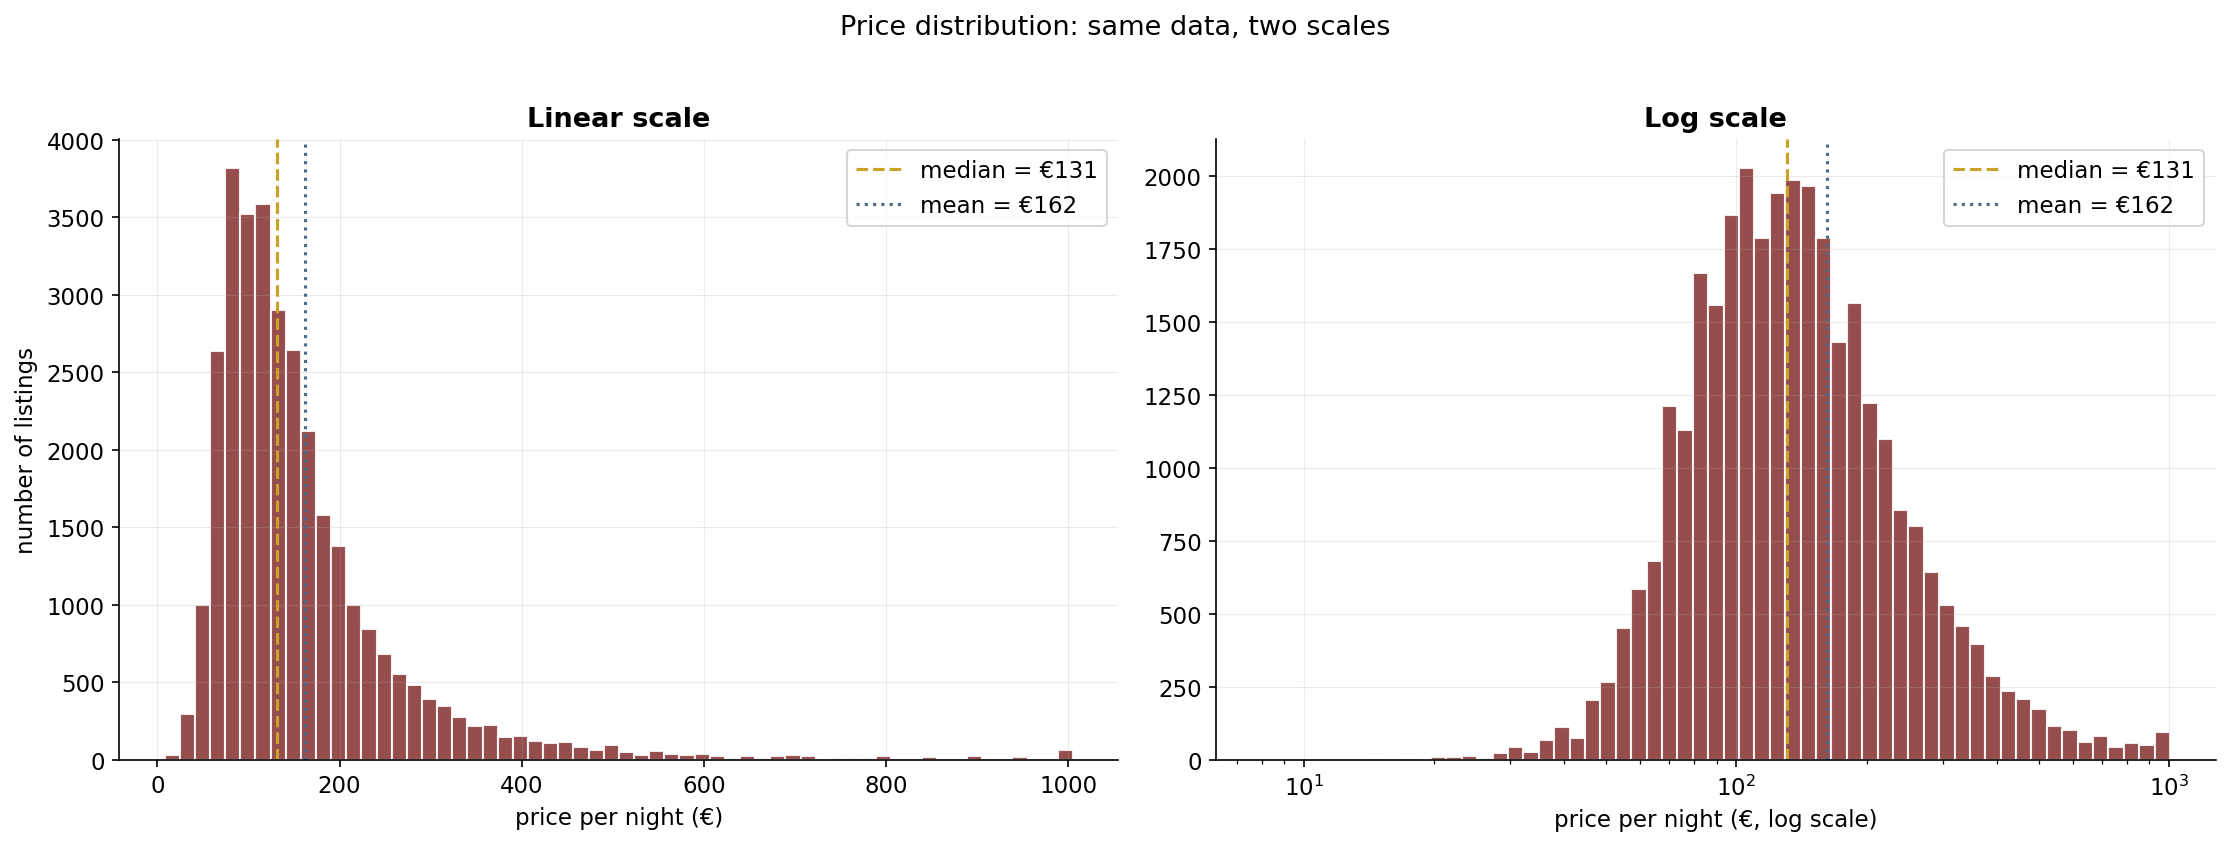

In [19]:
price_data = listings['price'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# left: raw shape
axes[0].hist(price_data, bins=60, color=ROME_PALETTE['primary'], edgecolor='white', alpha=0.9)
axes[0].axvline(price_data.median(), color=ROME_PALETTE['accent'], linestyle='--', linewidth=1.5,
                 label=f"median = €{price_data.median():.0f}")
axes[0].axvline(price_data.mean(), color=ROME_PALETTE['secondary'], linestyle=':', linewidth=1.5,
                 label=f"mean = €{price_data.mean():.0f}")
axes[0].set_xlabel('price per night (€)')
axes[0].set_ylabel('number of listings')
axes[0].set_title('Linear scale')
axes[0].legend()

# right: log scale
log_bins = np.logspace(np.log10(price_data.min()), np.log10(price_data.max()), 60)
axes[1].hist(price_data, bins=log_bins, color=ROME_PALETTE['primary'], edgecolor='white', alpha=0.9)
axes[1].set_xscale('log')
axes[1].axvline(price_data.median(), color=ROME_PALETTE['accent'], linestyle='--', linewidth=1.5,
                 label=f"median = €{price_data.median():.0f}")
axes[1].axvline(price_data.mean(), color=ROME_PALETTE['secondary'], linestyle=':', linewidth=1.5,
                 label=f"mean = €{price_data.mean():.0f}")
axes[1].set_xlabel('price per night (€, log scale)')
axes[1].set_title('Log scale')
axes[1].legend()

plt.suptitle('Price distribution: same data, two scales', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The gap between mean (€162) and median (€131) signals the right-skew visible in the histogram. The log-scale x-axis turns what would otherwise be a single dominant spike near zero into a clear, roughly symmetric bell around €70-100, confirming this is the natural scale for `price` in any downstream modeling.

Price is missing for 10.4% of listings. It is a gap traced back to the original scrape, unrelated to any text-coverage limitation documented in the NLP notebook. All price-based figures in this notebook use the 32,081 listings with a recorded value.

### 2.3 Price Tiers & Distribution Shape

/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_21541/1588021694.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  listings['price_tier'] = listings['price'].apply(assign_price_tier)


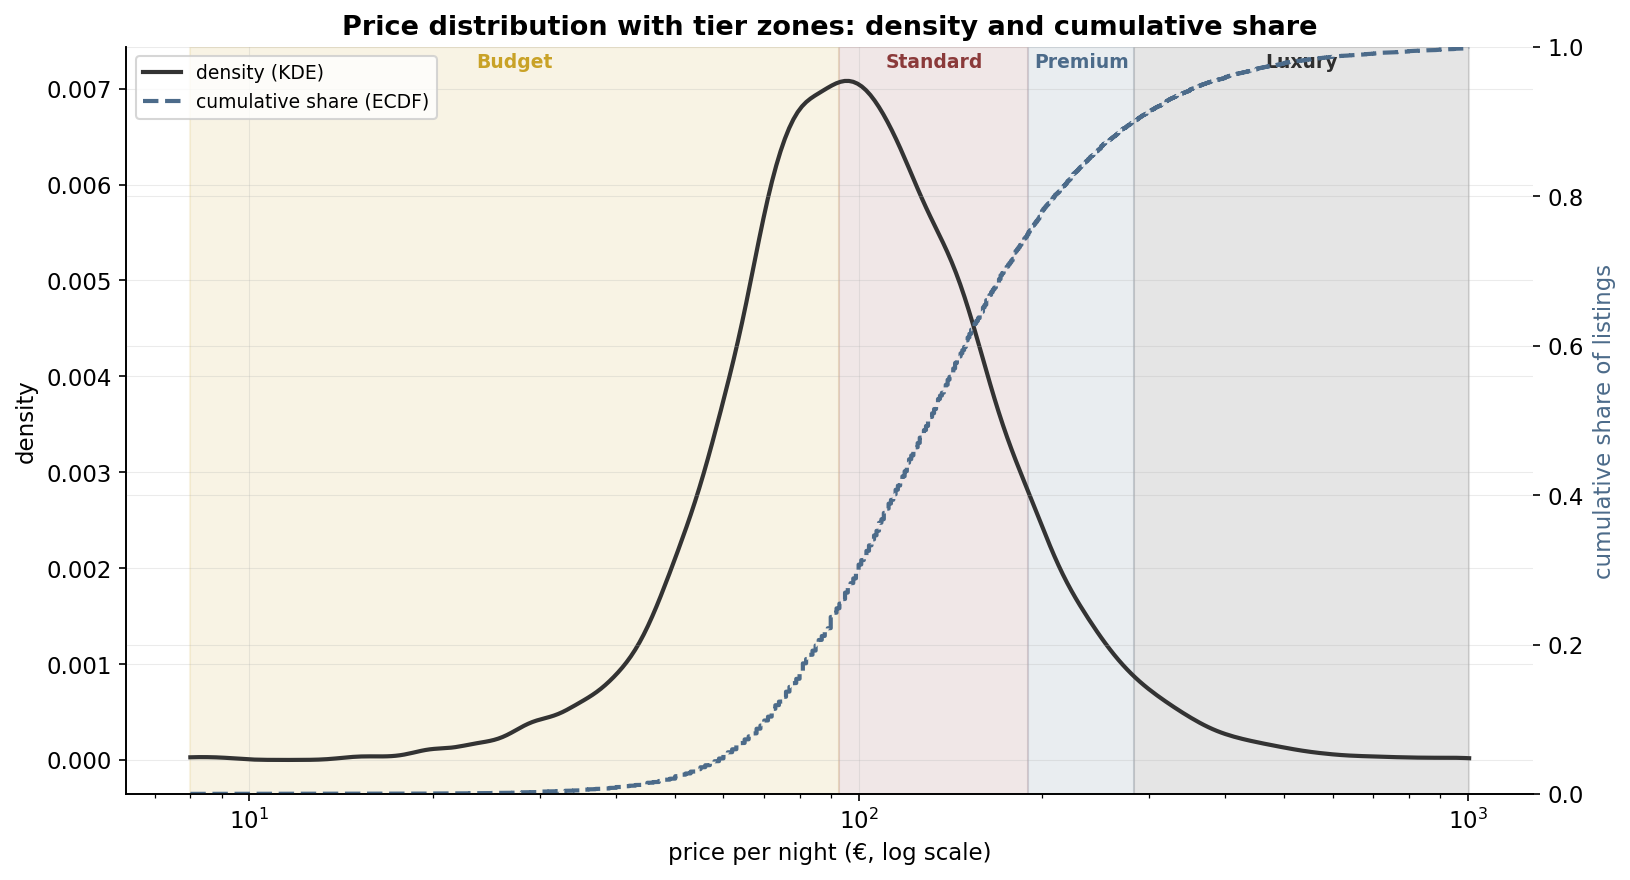

,count,pct,price_range (€)
price_tier,,,
Budget,7970,24.8,8–93
Standard,16051,50.0,93–190
Premium,4833,15.1,190–283
Luxury,3227,10.1,283–1005


In [21]:
from scipy.stats import gaussian_kde

q25, q75, q90 = price_data.quantile([0.25, 0.75, 0.90]).values
TIER_BOUNDS = [price_data.min(), q25, q75, q90, price_data.max()]
TIER_NAMES = ['Budget', 'Standard', 'Premium', 'Luxury']
TIER_COLORS = {'Budget': ROME_PALETTE['accent'], 'Standard': ROME_PALETTE['primary'],
               'Premium': ROME_PALETTE['secondary'], 'Luxury': '#2E2E2E'}

def assign_price_tier(p):
    if pd.isna(p):
        return np.nan
    if p < q25: return 'Budget'
    if p < q75: return 'Standard'
    if p < q90: return 'Premium'
    return 'Luxury'

listings['price_tier'] = listings['price'].apply(assign_price_tier)

fig, ax1 = plt.subplots(figsize=(11, 6))

log_price = np.log10(price_data)
kde = gaussian_kde(log_price)
x_grid = np.linspace(log_price.min(), log_price.max(), 300)
kde_vals = kde(x_grid) / (10**x_grid * np.log(10))

for i, name in enumerate(TIER_NAMES):
    ax1.axvspan(TIER_BOUNDS[i], TIER_BOUNDS[i+1], color=TIER_COLORS[name], alpha=0.12)
    mid = np.sqrt(TIER_BOUNDS[i] * TIER_BOUNDS[i+1])
    ax1.text(mid, kde_vals.max()*1.02, name, ha='center', fontsize=9, fontweight='bold', color=TIER_COLORS[name])

ax1.plot(10**x_grid, kde_vals, color='#333333', linewidth=2, label='density (KDE)')
ax1.set_xscale('log')
ax1.set_xlabel('price per night (€, log scale)')
ax1.set_ylabel('density')

ax2 = ax1.twinx()
sorted_price = np.sort(price_data)
ecdf_y = np.arange(1, len(sorted_price)+1) / len(sorted_price)
ax2.plot(sorted_price, ecdf_y, color=ROME_PALETTE['secondary'], linewidth=2, linestyle='--', label='cumulative share (ECDF)')
ax2.set_ylabel('cumulative share of listings', color=ROME_PALETTE['secondary'])
ax2.set_ylim(0, 1)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
ax1.set_title('Price distribution with tier zones: density and cumulative share')
plt.tight_layout()
plt.show()

tier_table = pd.DataFrame({
    'count': listings['price_tier'].value_counts().reindex(TIER_NAMES),
    'pct': listings['price_tier'].value_counts(normalize=True).mul(100).round(1).reindex(TIER_NAMES),
    'price_range (€)': [f"{TIER_BOUNDS[i]:.0f}–{TIER_BOUNDS[i+1]:.0f}" for i in range(4)],
})
display(tier_table)

The KDE peaks inside the Standard tier (€93-190), confirming this tier isn't an arbitrary quartile split but genuinely tracks where the market's mass sits, as half of all listings fall here, and it's visibly the single most crowded price zone on the chart. The ECDF's steepest climb happens across Budget→Standard, meaning small price movements in that range shift a large share of the market. By contrast, the flat ECDF tail through Premium and especially Luxury shows those tiers cover a huge price range (€283-1,005) for comparatively few listings, meaning the market thins out fast once prices climb past the median.

### 2.4 What Are People Renting?

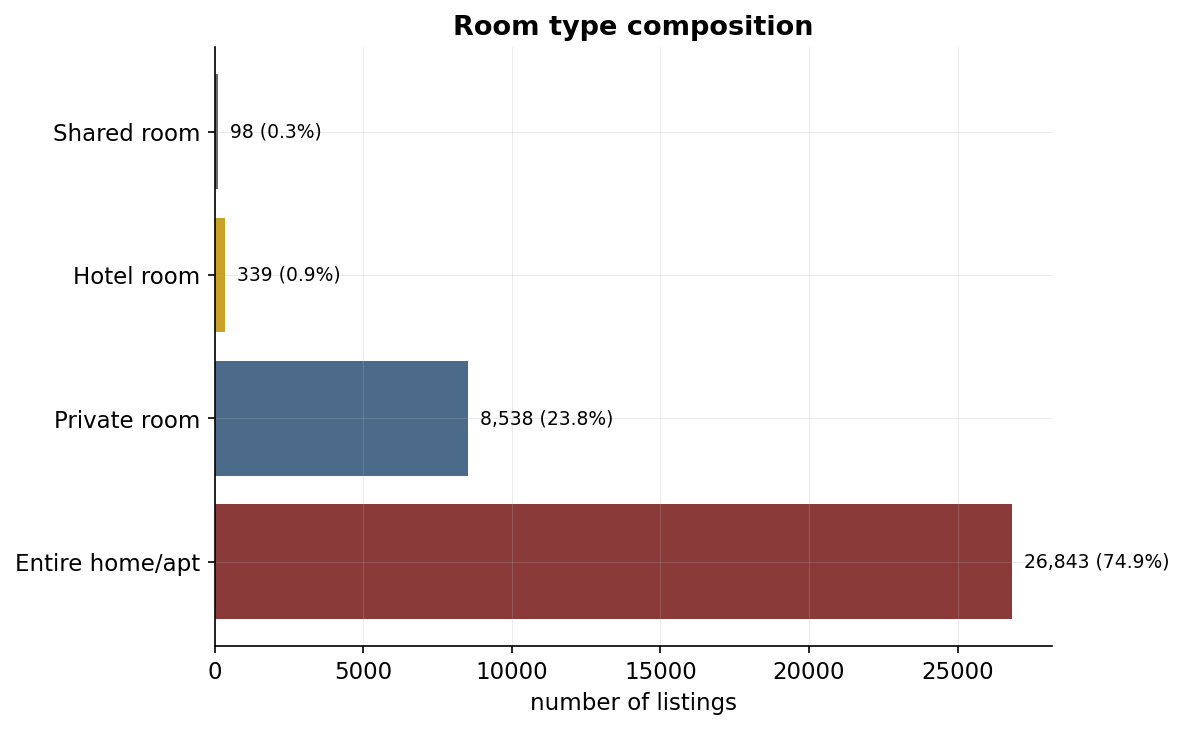

,count,pct
room_type,,
Entire home/apt,26843,74.9
Private room,8538,23.8
Hotel room,339,0.9
Shared room,98,0.3


In [ ]:
room_type_counts = listings['room_type'].value_counts()
room_type_pct = listings['room_type'].value_counts(normalize=True).mul(100).round(1)

fig, ax = plt.subplots(figsize=(8, 5))
colors = [ROME_PALETTE['primary'], ROME_PALETTE['secondary'], ROME_PALETTE['accent'], ROME_PALETTE['neutral']]
ax.barh(room_type_counts.index, room_type_counts.values, color=colors[:len(room_type_counts)])
for i, (count, pct) in enumerate(zip(room_type_counts.values, room_type_pct.values)):
    ax.text(count, i, f'  {count:,} ({pct}%)', va='center', fontsize=9)
ax.set_xlabel('number of listings')
ax.set_title('Room type composition')
plt.tight_layout()
plt.show()

room_type_table = pd.DataFrame({'count': room_type_counts, 'pct': room_type_pct})
display(room_type_table)

The market is overwhelmingly `Entire home/apt` (74.9%), so it is a market of whole-unit rentals, not shared accommodation. `Private room` is a real but distinctly secondary segment (23.8%), while `Hotel room` and `Shared room` combined barely register (1.2%).

### 2.5 Property Type & Size

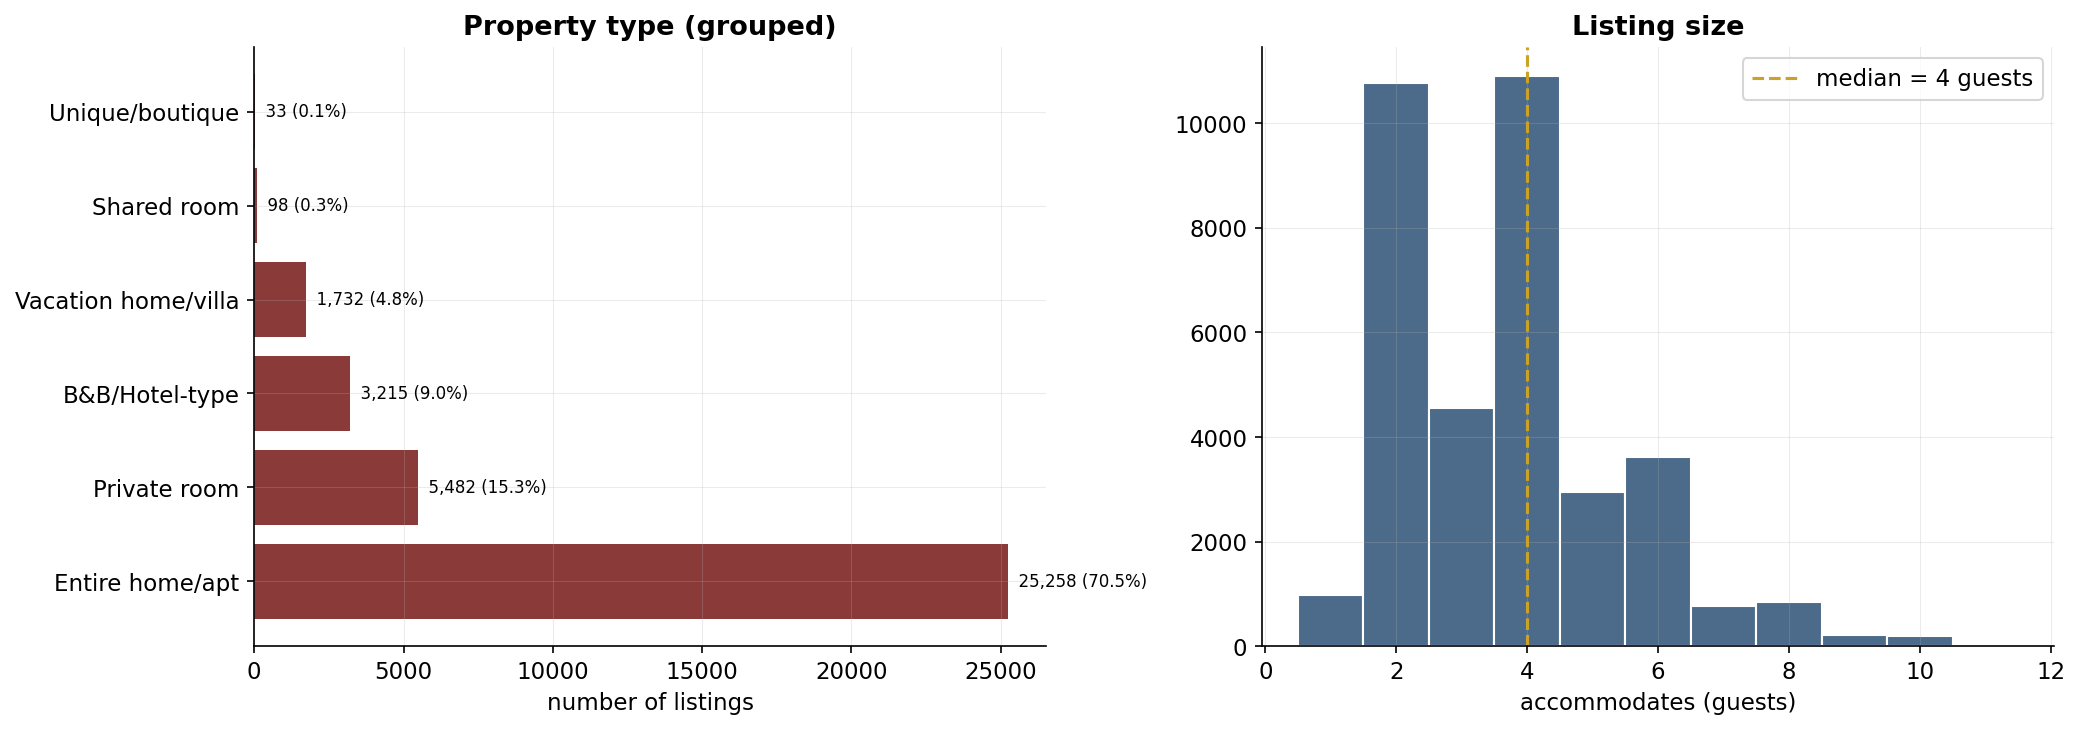

,count,pct
property_type_grouped,,
Entire home/apt,25258,70.5
Private room,5482,15.3
B&B/Hotel-type,3215,9.0
Vacation home/villa,1732,4.8
Shared room,98,0.3
Unique/boutique,33,0.1


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

prop_counts = listings['property_type_grouped'].value_counts()
prop_pct = listings['property_type_grouped'].value_counts(normalize=True).mul(100).round(1)
axes[0].barh(prop_counts.index, prop_counts.values, color=ROME_PALETTE['primary'])
for i, (count, pct) in enumerate(zip(prop_counts.values, prop_pct.values)):
    axes[0].text(count, i, f'  {count:,} ({pct}%)', va='center', fontsize=8)
axes[0].set_xlabel('number of listings')
axes[0].set_title('Property type (grouped)')

accommodates_data = listings['accommodates'].dropna()
axes[1].hist(accommodates_data, bins=range(1, int(accommodates_data.max())+2), align='left',
             color=ROME_PALETTE['secondary'], edgecolor='white')
axes[1].axvline(accommodates_data.median(), color=ROME_PALETTE['accent'], linestyle='--', linewidth=1.5,
                 label=f"median = {accommodates_data.median():.0f} guests")
axes[1].set_xlabel('accommodates (guests)')
axes[1].set_title('Listing size')
axes[1].legend()

plt.tight_layout()
plt.show()

prop_table = pd.DataFrame({'count': prop_counts, 'pct': prop_pct})
display(prop_table)

`property_type_grouped` tells a richer story than `room_type` alone: within the 74.9% "Entire home/apt" room-type share, a full third actually splits into more specific building types once `property_type_grouped` is applied. `B&B/Hotel-type` (9.0%) and `Vacation home/villa` (4.8%) both count as "entire place" under `room_type` but represent structurally distinct offerings.

Listing size clusters tightly around small-to-mid units: median 4 guests, with a sharp mode at 2 and a visible secondary bump at 4, consistent with a market built for couples and small families.

### 2.6 Price per Person vs. Capacity

/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_21541/174569037.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  listings['price_per_person'] = listings['price'] / listings['accommodates']


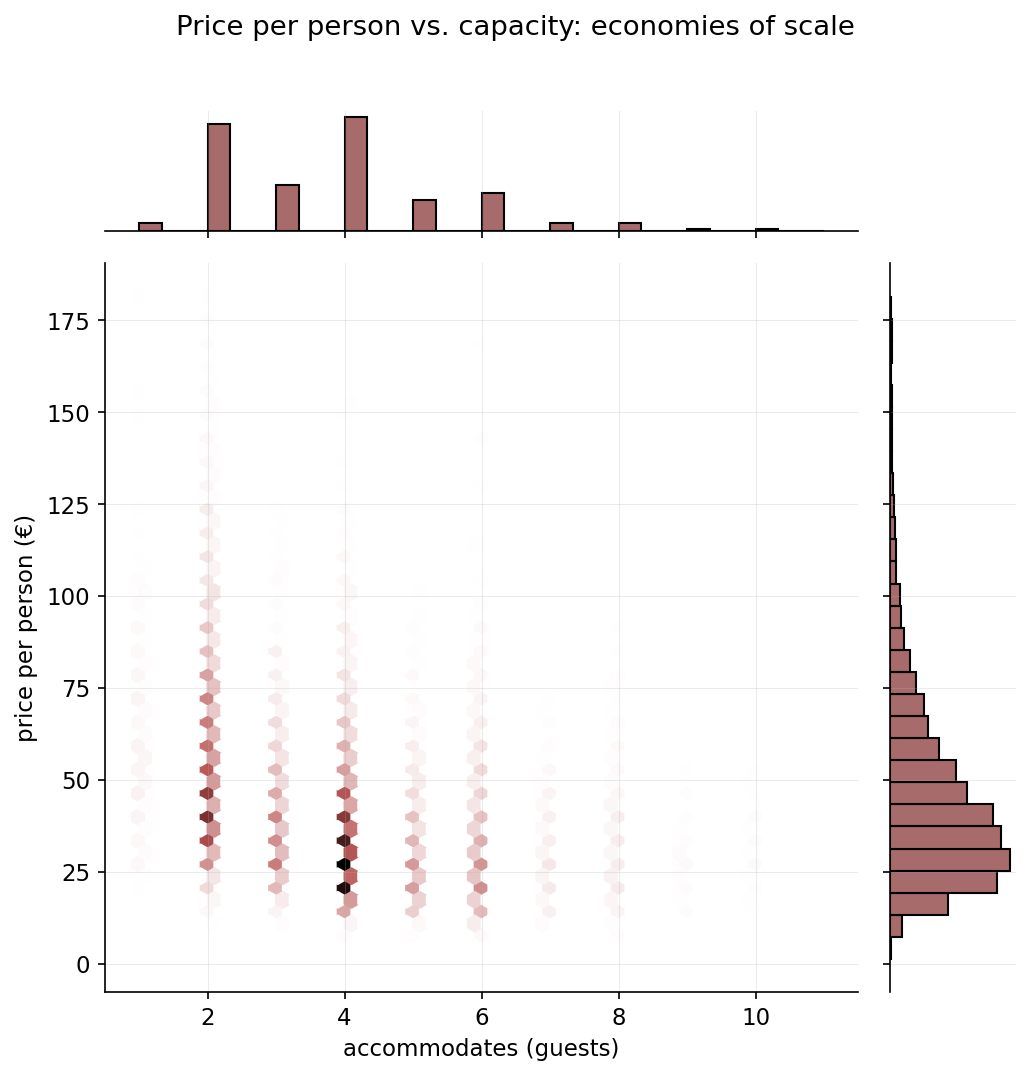

,median €/person
accommodates,
1,62.0
2,53.0
3,39.2
4,33.5
5,30.4
6,31.2
7,30.9
8,33.9
9,30.9


In [22]:
listings['price_per_person'] = listings['price'] / listings['accommodates']

joint_data = listings.dropna(subset=['price_per_person', 'accommodates']).copy()
joint_data = joint_data[joint_data['price_per_person'] <= joint_data['price_per_person'].quantile(0.99)]

g = sns.jointplot(data=joint_data, x='accommodates', y='price_per_person', kind='hex',
                   color=ROME_PALETTE['primary'], height=7,
                   marginal_kws=dict(bins=30, color=ROME_PALETTE['primary']))
g.ax_joint.set_xlabel('accommodates (guests)')
g.ax_joint.set_ylabel('price per person (€)')
g.fig.suptitle('Price per person vs. capacity: economies of scale', y=1.02)
plt.tight_layout()
plt.show()

display(joint_data.groupby('accommodates')['price_per_person'].median().round(1).to_frame('median €/person'))

The darkest hexbins sit at `accommodates=2` (€40-55/person) and `accommodates=4` (€25-35/person), which are the market's two dominant configurations. The median table confirms the economy-of-scale hypothesis directly: price per person drops steeply from €62 (solo travelers) to roughly €30-33 by accommodates=4-5, then flattens, meaning beyond 4 guests, adding capacity barely changes the per-person cost. This means that a solo traveler and a family of four are paying structurally different rates for the same underlying unit type.

### 2.7 Bed Capacity Concentration

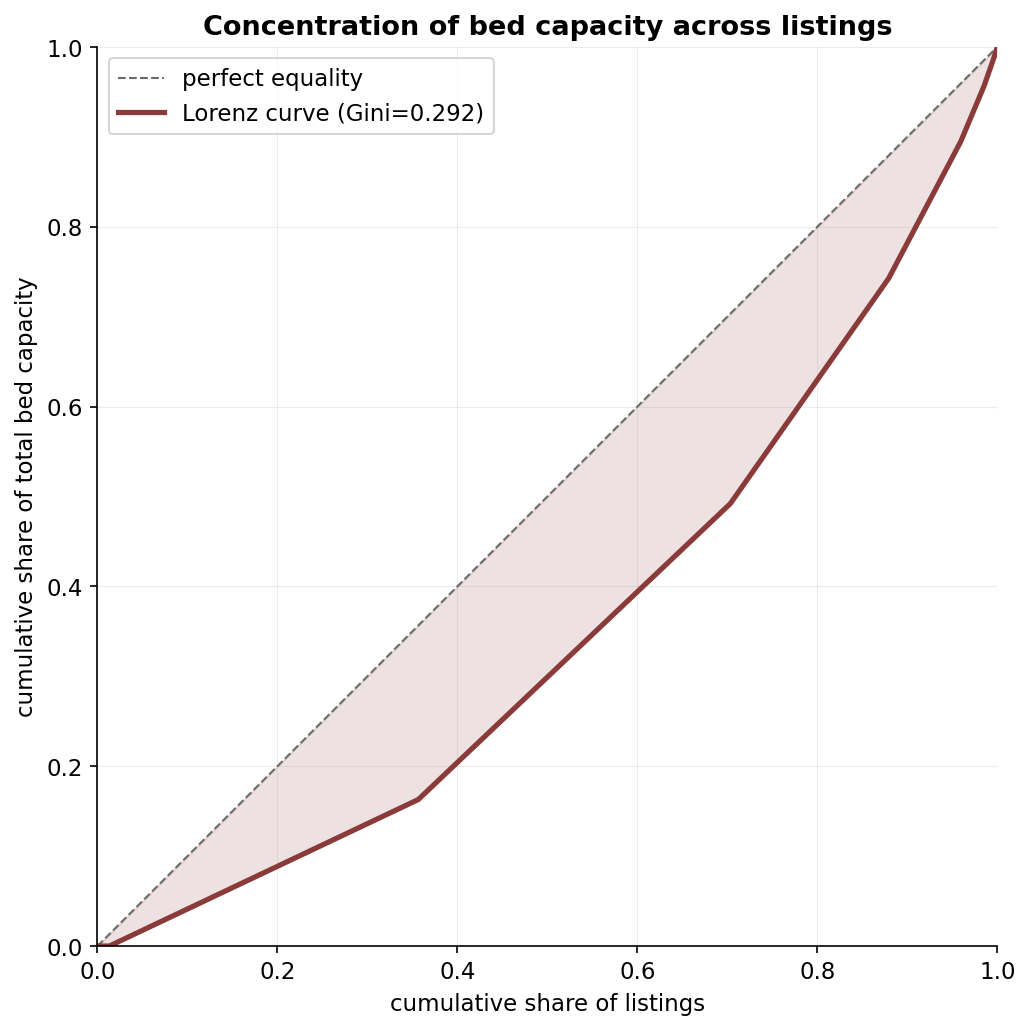

Gini coefficient: 0.292
bottom 50% of listings hold 29.9% of total bed capacity
top 10% of listings hold 21.8% of total bed capacity


In [26]:
listings['beds_restored'] = np.expm1(listings['beds_log'])
beds_sorted = listings['beds_restored'].dropna().sort_values().values
n = len(beds_sorted)
cum_listings_pct = np.arange(1, n+1) / n
cum_beds_pct = np.cumsum(beds_sorted) / beds_sorted.sum()
gini = 1 - 2 * np.trapezoid(cum_beds_pct, cum_listings_pct)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], color=ROME_PALETTE['neutral'], linestyle='--', linewidth=1, label='perfect equality')
ax.plot(cum_listings_pct, cum_beds_pct, color=ROME_PALETTE['primary'], linewidth=2.5, label=f'Lorenz curve (Gini={gini:.3f})')
ax.fill_between(cum_listings_pct, cum_listings_pct, cum_beds_pct, color=ROME_PALETTE['primary'], alpha=0.15)
ax.set_xlabel('cumulative share of listings')
ax.set_ylabel('cumulative share of total bed capacity')
ax.set_title('Concentration of bed capacity across listings')
ax.legend(loc='upper left')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print(f"Gini coefficient: {gini:.3f}")
print(f"bottom 50% of listings hold {cum_beds_pct[int(n*0.5)]*100:.1f}% of total bed capacity")
print(f"top 10% of listings hold {(1 - cum_beds_pct[int(n*0.9)])*100:.1f}% of total bed capacity")

Gini=0.292 is a mild concentration. The bottom 50% of listings hold nearly 30% of total capacity (not the ~10-20% a more skewed market would show), and the top 10% hold only 21.8%. This is a market of broadly similar-sized units, not one polarized between many tiny listings and a few large complexes, which has a direct implication for clustering: `beds`/`accommodates` alone likely won't produce a dramatic high-capacity outlier segment on their own.

### 2.8 Supply Volume: Price Tier × Capacity

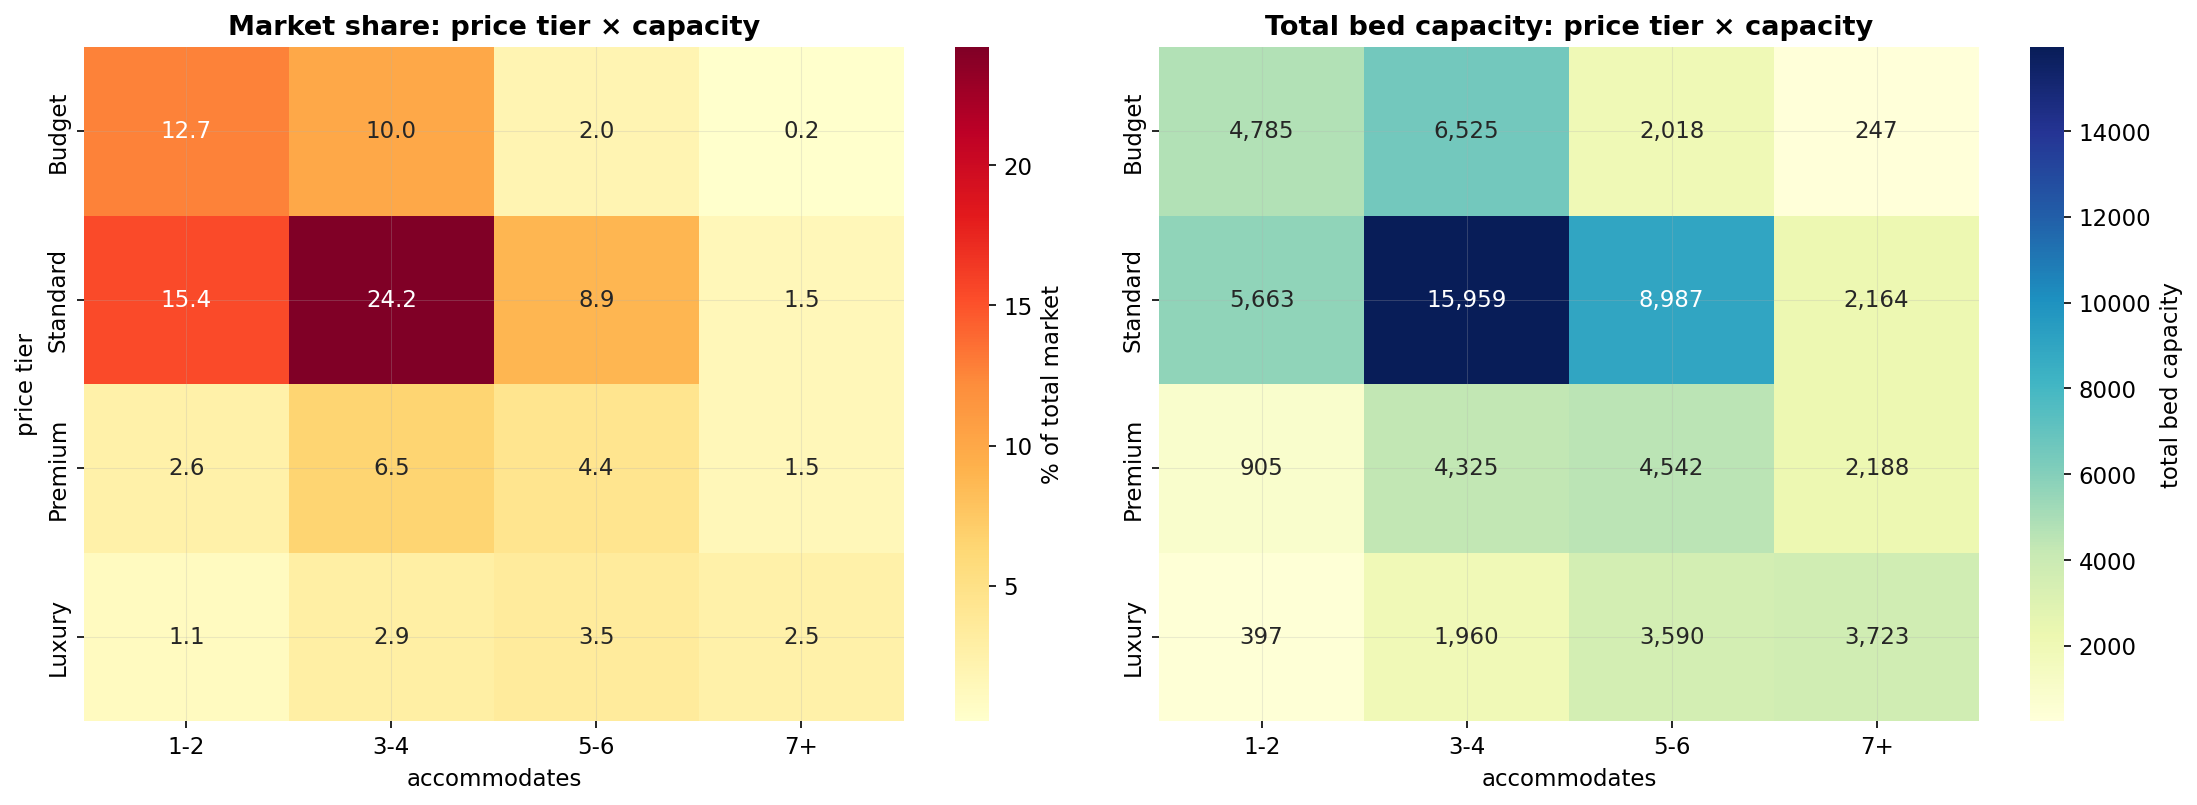

In [28]:
def bin_accommodates(a):
    if pd.isna(a): return np.nan
    if a <= 2: return '1-2'
    if a <= 4: return '3-4'
    if a <= 6: return '5-6'
    return '7+'

listings['accommodates_bin'] = listings['accommodates'].apply(bin_accommodates)
ACC_BINS = ['1-2', '3-4', '5-6', '7+']

matrix_data = listings.dropna(subset=['price_tier', 'accommodates_bin', 'beds_restored'])
pct_matrix = pd.crosstab(matrix_data['price_tier'], matrix_data['accommodates_bin'], normalize='all').mul(100).reindex(index=TIER_NAMES, columns=ACC_BINS)
beds_matrix = matrix_data.pivot_table(index='price_tier', columns='accommodates_bin', values='beds_restored', aggfunc='sum').reindex(index=TIER_NAMES, columns=ACC_BINS)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.heatmap(pct_matrix, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': '% of total market'}, ax=axes[0])
axes[0].set_title('Market share: price tier × capacity')
axes[0].set_xlabel('accommodates'); axes[0].set_ylabel('price tier')

sns.heatmap(beds_matrix, annot=True, fmt=',.0f', cmap='YlGnBu', cbar_kws={'label': 'total bed capacity'}, ax=axes[1])
axes[1].set_title('Total bed capacity: price tier × capacity')
axes[1].set_xlabel('accommodates'); axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

The single densest cell on the entire market Standard price × 3-4 guests (24.2% of all listings) confirms this is the market's true center of gravity. Reading the two matrices together reveals a subtlety the left matrix alone hides: Standard/3-4 also dominates total bed volume (15,959 beds, more than double any other cell), meaning this segment isn't just numerous, it's structurally the market's backbone in terms of actual sleeping capacity supplied to guests. Luxury listings are thin in count but skew toward larger units. The Luxury/7+ cell holds more total beds (3,723) than three of its four Luxury row-mates combined, suggesting high-end listings compete less on quantity and more on hosting larger groups at a premium.

### 2.9 Market Overview Summary

Rome's Airbnb market has a clear, consistent shape running through every angle examined here. It's dominated by whole-unit rentals sized for couples and small families, priced in a right-skewed but genuinely log-normal distribution with half the market sitting in a €93-190 Standard band. The single most common configuration, Standard-priced, 3-4-guest units, isn't just the largest listing count but also the backbone of total sleeping capacity supplied.

Two structural patterns matter directly for what comes next. First, price doesn't scale linearly with capacity: solo travelers pay roughly double the per-person rate of a group of four, meaning group size is a real economic axis, not just a size detail. Second, bed capacity is only mildly concentrated, meaning this is a market of broadly similar-sized units, not one split between many tiny listings and a few large complexes, so extreme capacity outliers are unlikely to define a cluster on their own.

Luxury listings are a genuine minority by count, but skew toward larger units, competing on group size and premium positioning rather than volume.

## 3. Geography of the Market

Every finding so far has been a market-wide average, blind to *where* in Rome it holds. But Rome's Airbnb market isn't uniform: a listing's price, size, and type are deeply entangled with its location, from the tourist-dense historic core to the quiet residential periphery. This section makes that geography explicit, mapping the market's structure directly onto the city rather than describing it in the abstract.

### 3.1 Setup: Point-in-Polygon Sanity Check

In [29]:
from shapely.geometry import Point

print(f"neighbourhoods CRS: {neighbourhoods.crs}")

listings_with_coords = listings.dropna(subset=['latitude', 'longitude']).copy()
geometry = [Point(xy) for xy in zip(listings_with_coords['longitude'], listings_with_coords['latitude'])]
listings_geo = gpd.GeoDataFrame(listings_with_coords, geometry=geometry, crs='EPSG:4326')

if neighbourhoods.crs != listings_geo.crs:
    neighbourhoods = neighbourhoods.to_crs(listings_geo.crs)

print(f"listings with valid coordinates: {len(listings_geo):,} / {len(listings):,}")

neighbourhoods CRS: EPSG:4326
listings with valid coordinates: 35,818 / 35,818


In [30]:
joined = gpd.sjoin(listings_geo, neighbourhoods[['neighbourhood', 'geometry']], how='left', predicate='within')

n_outside = joined['neighbourhood'].isna().sum()
print(f"listings falling outside all municipio polygons: {n_outside:,} ({n_outside/len(joined)*100:.2f}%)")

n_mismatch = (joined['neighbourhood'] != joined['neighbourhood_cleansed']).sum()
print(f"listings where spatial join disagrees with recorded neighbourhood_cleansed: {n_mismatch:,} "
      f"({n_mismatch/len(joined)*100:.2f}%)")

listings falling outside all municipio polygons: 0 (0.00%)
listings where spatial join disagrees with recorded neighbourhood_cleansed: 1 (0.00%)


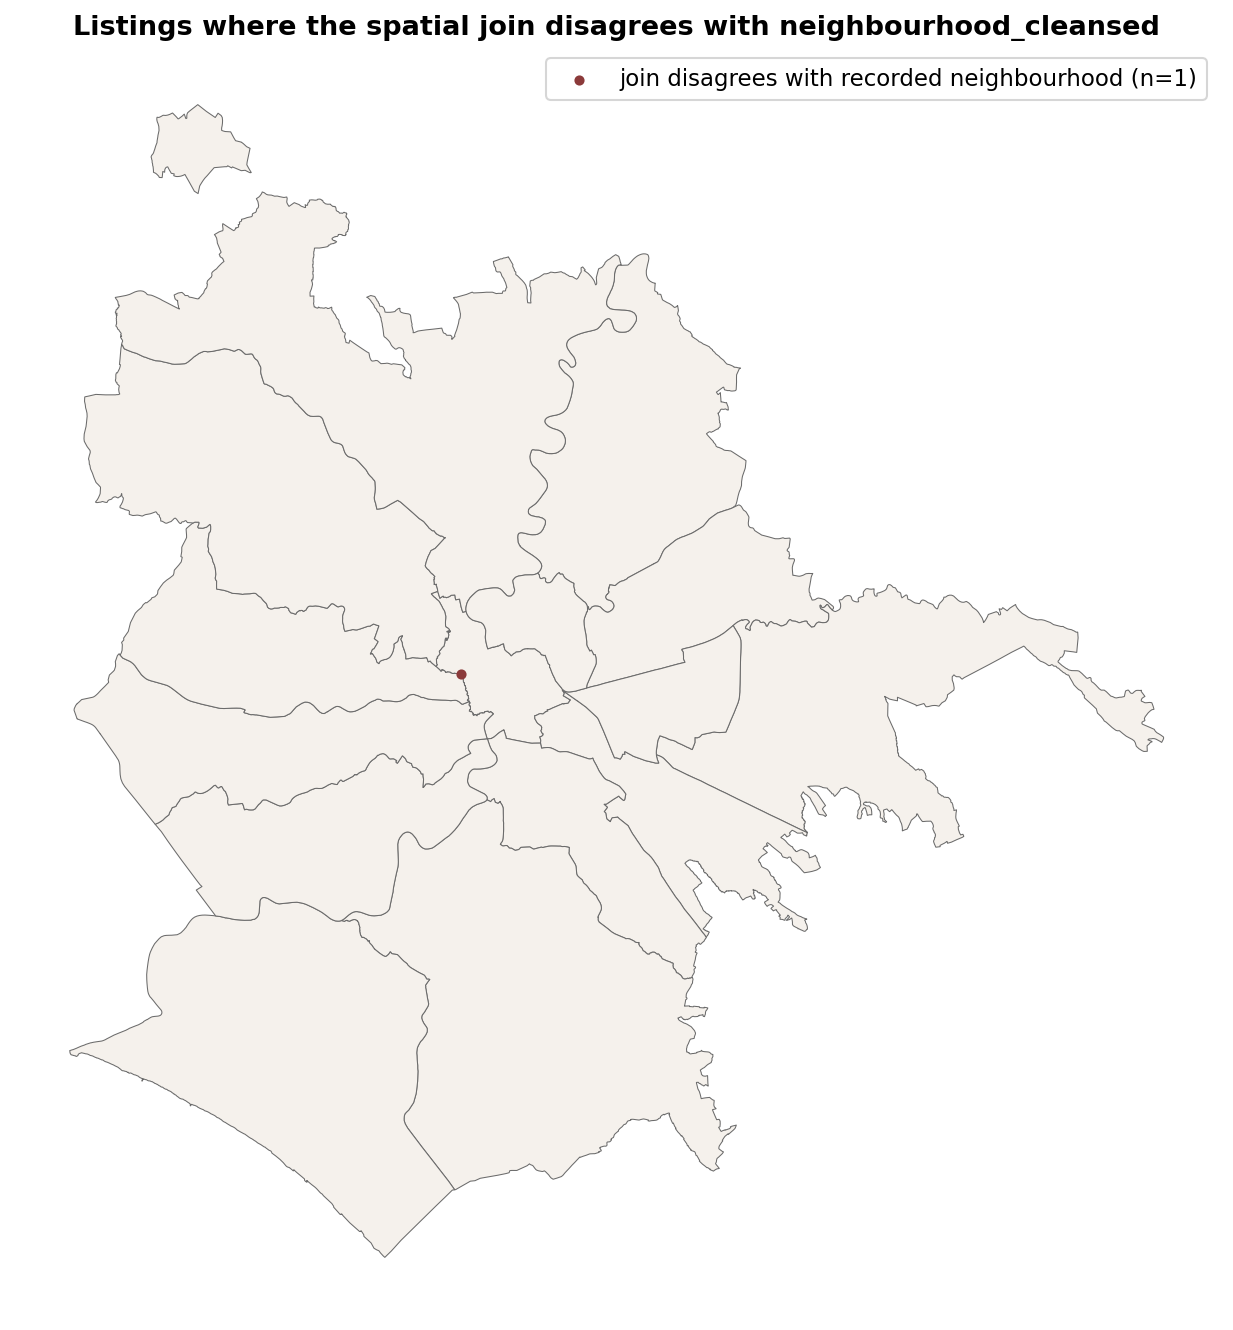

In [33]:
if n_mismatch > 0:
    fig, ax = plt.subplots(figsize=(9, 9))
    neighbourhoods.plot(ax=ax, color=ROME_PALETTE['light_bg'], edgecolor=ROME_PALETTE['neutral'], linewidth=0.5)
    mismatch_pts = joined[joined['neighbourhood'] != joined['neighbourhood_cleansed']]
    ax.scatter(mismatch_pts.geometry.x, mismatch_pts.geometry.y, color=ROME_PALETTE['primary'], s=15, zorder=3,
               label=f'join disagrees with recorded neighbourhood (n={n_mismatch})')
    ax.set_title('Listings where the spatial join disagrees with neighbourhood_cleansed')
    ax.legend()
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
else:
    print("no mismatches to plot — spatial join fully agrees with recorded neighbourhood_cleansed")

The one mismatch sits exactly on a municipio boundary line, where two district edges converge near the city center. It is a coordinate-precision edge case, not a data quality problem. At 1 listing out of 35,818 (0.00%), this has zero practical effect on any subsequent map or aggregation. The spatial join and `neighbourhood_cleansed` are in complete agreement for all practical purposes.

### 3.2 Listing Density

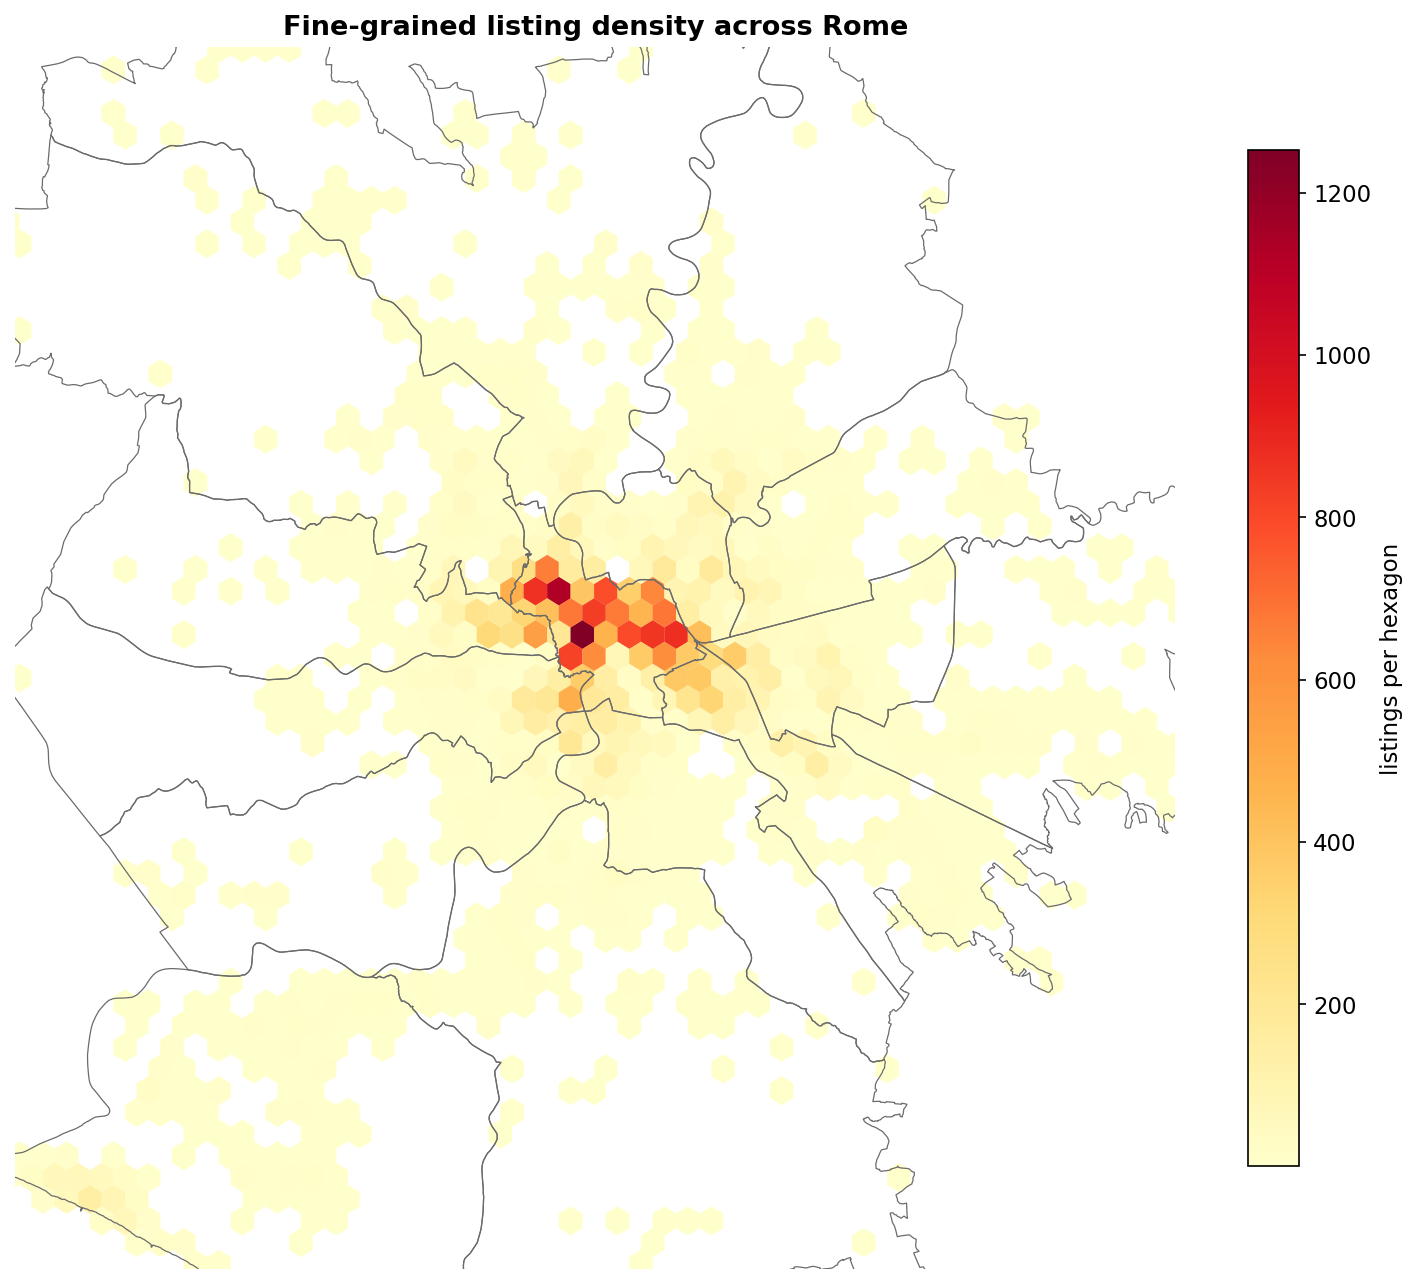

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:840: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


,metric,value
0,Non-empty hexagons,927
1,Max listings in one hexagon,1252
2,Median listings per non-empty hexagon,4
3,Hexagons with 1 listing only,226 (24.4%)
4,Hexagons in top 5% (densest),47


In [36]:
# constrain the plot to where listings actually are
lon_min, lon_max = listings_geo.geometry.x.quantile([0.001, 0.999])
lat_min, lat_max = listings_geo.geometry.y.quantile([0.001, 0.999])
pad = 0.01

fig, ax = plt.subplots(figsize=(10, 10))
neighbourhoods.plot(ax=ax, color='none', edgecolor=ROME_PALETTE['neutral'], linewidth=0.6, zorder=2)

hb = ax.hexbin(listings_geo.geometry.x, listings_geo.geometry.y, gridsize=65, cmap='YlOrRd',
                mincnt=1, zorder=1, linewidths=0.1)
cb = plt.colorbar(hb, ax=ax, shrink=0.7, label='listings per hexagon')

ax.set_xlim(lon_min - pad, lon_max + pad)
ax.set_ylim(lat_min - pad, lat_max + pad)
ax.set_title('Fine-grained listing density across Rome')
ax.set_axis_off()
plt.tight_layout()
plt.show()

counts = hb.get_array()
counts = counts[counts > 0]

density_summary = pd.DataFrame({
    'metric': ['Non-empty hexagons', 'Max listings in one hexagon', 'Median listings per non-empty hexagon',
               'Hexagons with 1 listing only', 'Hexagons in top 5% (densest)'],
    'value': [
        f"{len(counts):,}",
        f"{counts.max():.0f}",
        f"{np.median(counts):.0f}",
        f"{(counts == 1).sum():,} ({(counts==1).mean()*100:.1f}%)",
        f"{(counts >= np.percentile(counts, 95)).sum():,}",
    ]
})
display(density_summary)

The concentration is stark: a handful of hexagons in the historic center reach over 1,200 listings, while the median non-empty hexagon holds just 4. It is a nearly 300x gap between the densest cell and the typical one. Almost a quarter of all occupied hexagons (24.4%) contain exactly one listing, confirming this is a market with an extreme long tail of sparse, scattered presence surrounding one unmistakable hyper-dense core. The darkest cluster sits visibly inside a single municipio's boundary.

### 3.3 Listing Density — Administrative

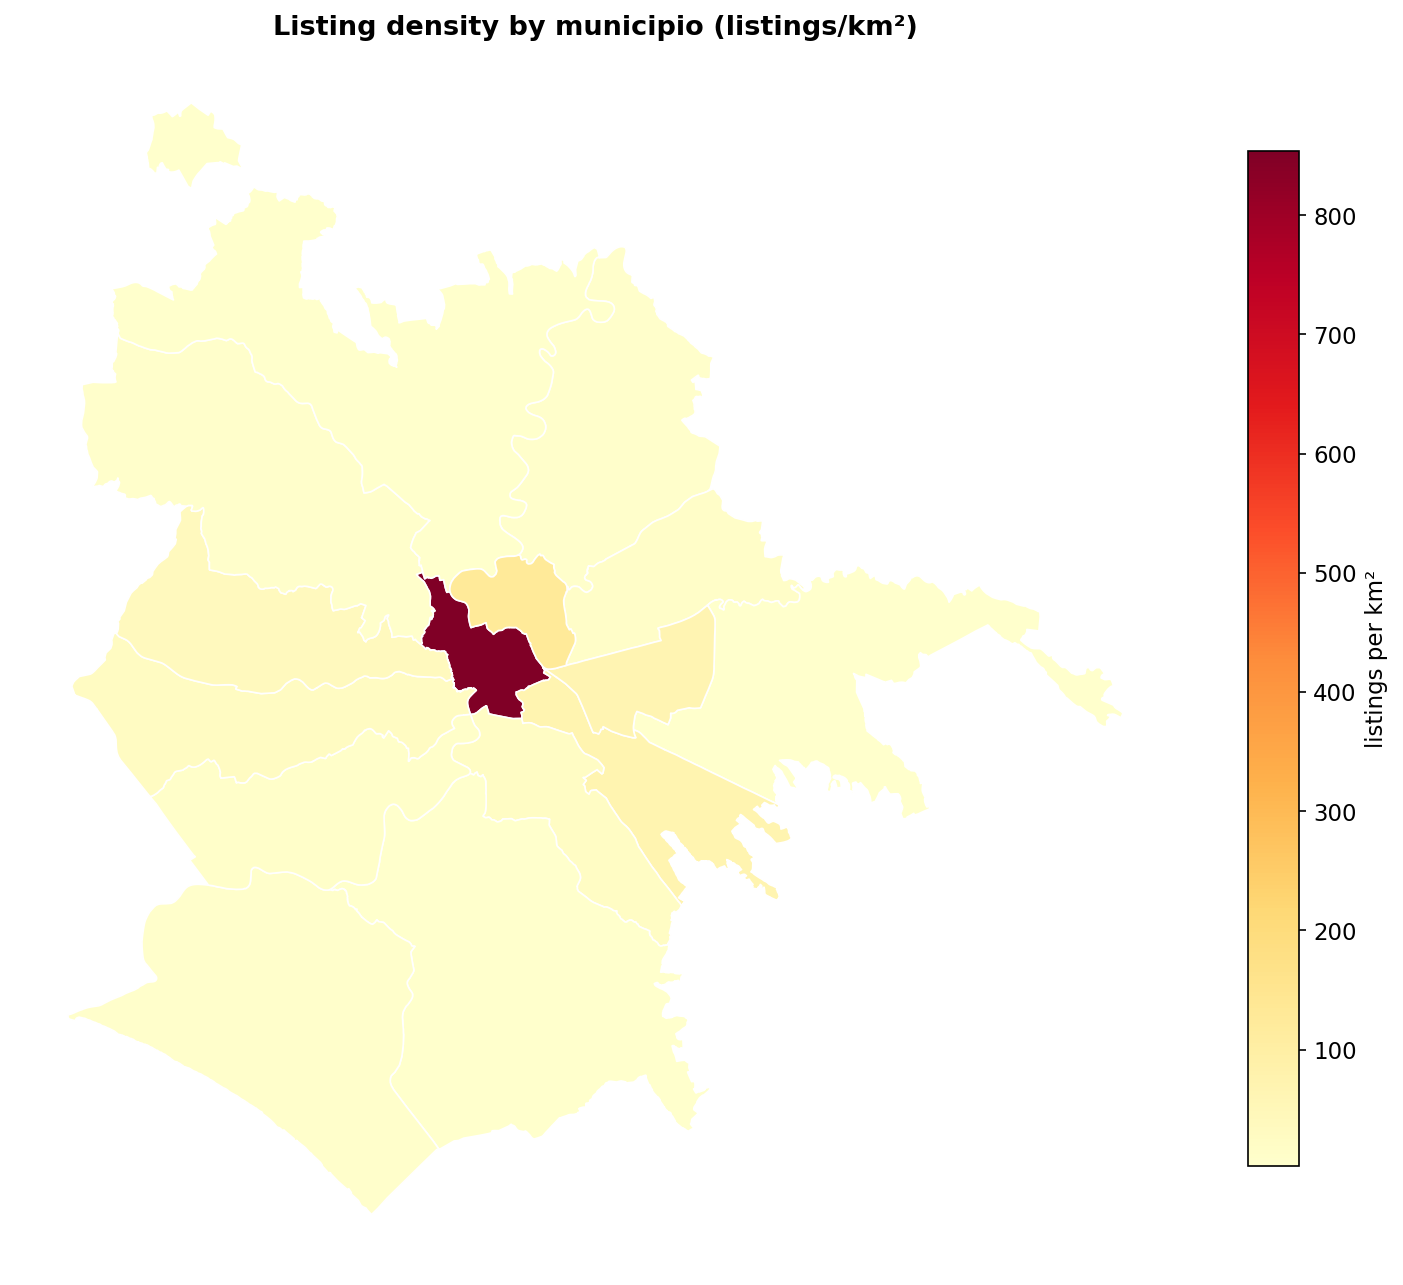

,neighbourhood,listing_count,area_km2,density_per_km2
0,I Centro Storico,17537,20.5,854.0
14,II Parioli/Nomentano,2473,19.5,126.7
4,VII San Giovanni/Cinecittà,3138,45.4,69.1
13,V Prenestino/Centocelle,1836,27.0,68.1
10,XIII Aurelia,2560,67.2,38.1
9,XII Monte Verde,1934,73.0,26.5
5,VIII Appia Antica,1155,47.4,24.4
2,IV Tiburtina,658,49.2,13.4
8,XI Arvalia/Portuense,756,71.4,10.6
7,X Ostia/Acilia,1020,152.8,6.7


In [37]:
neighbourhoods_proj = neighbourhoods.to_crs(neighbourhoods.estimate_utm_crs())
neighbourhoods['area_km2'] = neighbourhoods_proj.geometry.area / 1e6

listing_counts_by_municipio = listings['neighbourhood_cleansed'].value_counts()
neighbourhoods['listing_count'] = neighbourhoods['neighbourhood'].map(listing_counts_by_municipio)
neighbourhoods['density_per_km2'] = neighbourhoods['listing_count'] / neighbourhoods['area_km2']

fig, ax = plt.subplots(figsize=(10, 10))
neighbourhoods.plot(column='density_per_km2', ax=ax, cmap='YlOrRd', edgecolor='white', linewidth=0.8,
                     legend=True, legend_kwds={'label': 'listings per km²', 'shrink': 0.7})
ax.set_title('Listing density by municipio (listings/km²)')
ax.set_axis_off()
plt.tight_layout()
plt.show()

density_table = neighbourhoods[['neighbourhood', 'listing_count', 'area_km2', 'density_per_km2']].sort_values(
    'density_per_km2', ascending=False
).round(1)
display(density_table)

I Centro Storico dominates by a wide margin: 854 listings/km², nearly 7x the second-densest district (II Parioli/Nomentano, 126.7/km²) and almost 400x the sparsest (IX Eur, 2.2/km²). This single municipio holds roughly **49% of the entire market in one district covering just 20.5 km²**, a number the fine-grained hexbin map only hinted at. Density then falls off in a clean, near-monotonic staircase moving outward from the center, with no secondary hotspot anywhere in the city, meaning Rome's Airbnb market has exactly one center of gravity, not several competing districts.

X Ostia/Acilia, the coastal district independently identified as a distinct sub-market in the NLP notebook's `text_persona` analysis, sits near the bottom of this list (6.7/km², 11th of 15), confirming it's a real but genuinely peripheral segment by volume, not a hidden second hub the density map would have surfaced on its own.

### 3.4 Price by District

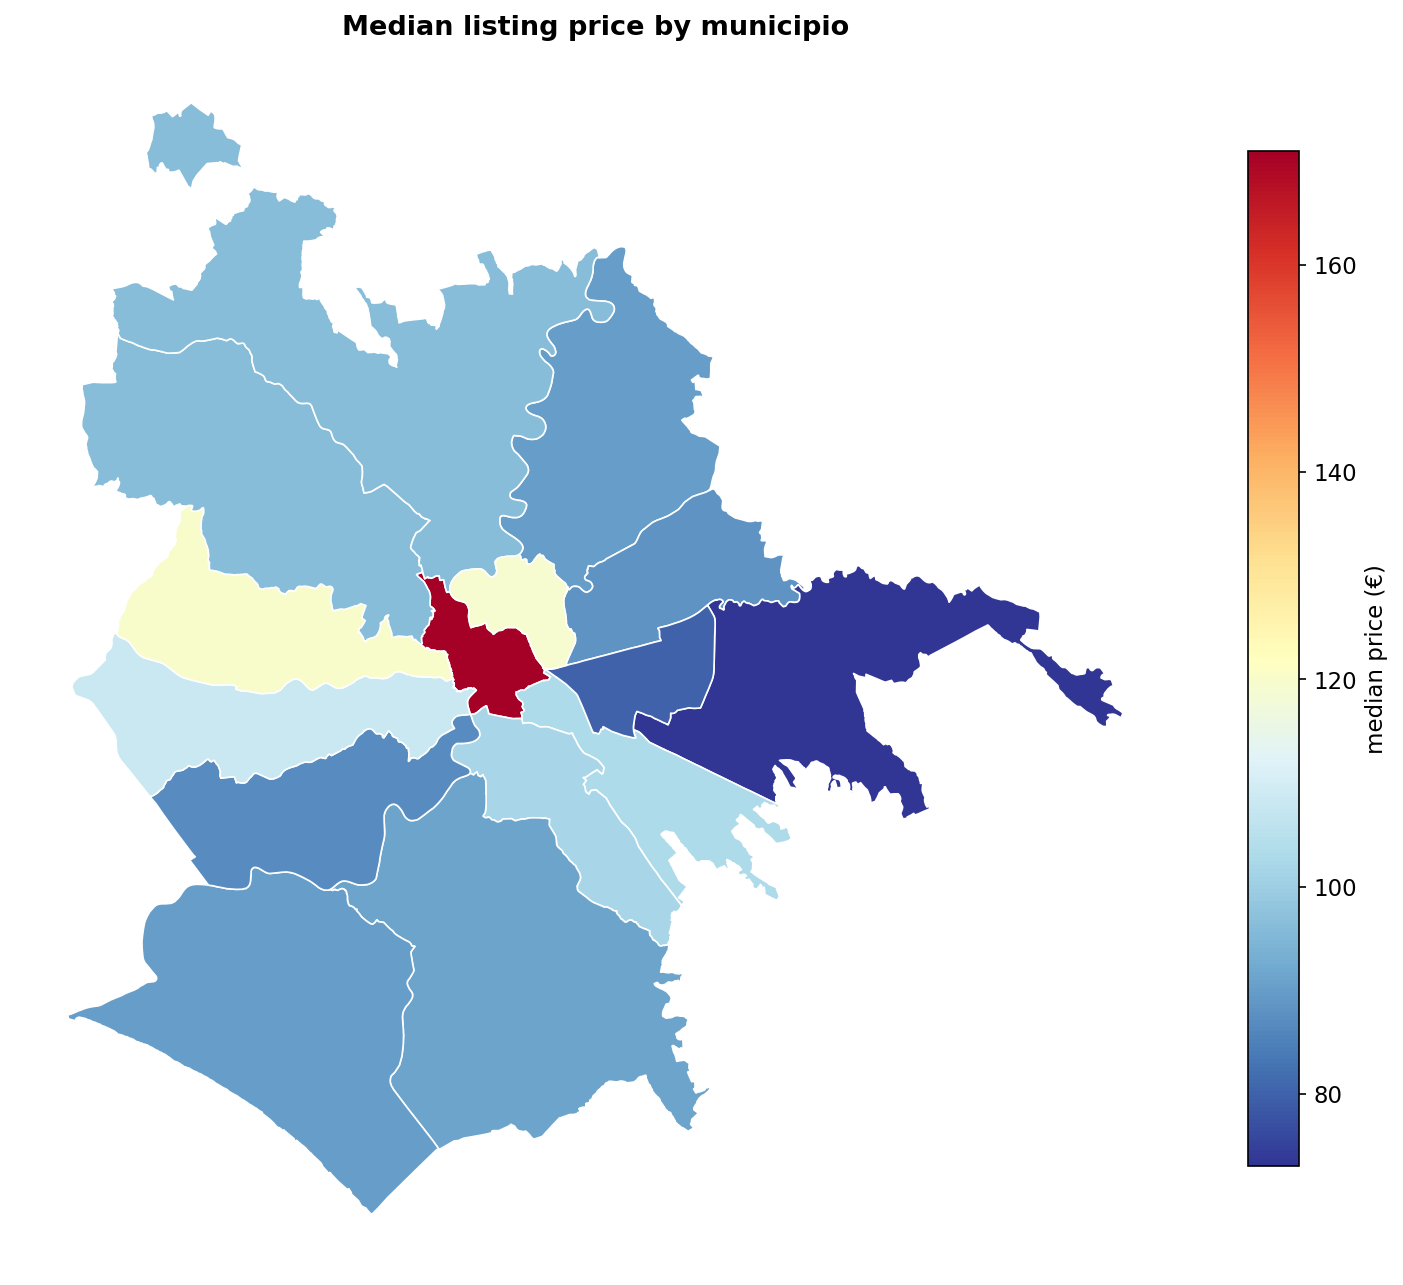

,neighbourhood,median_price,price_n,density_per_km2
0,I Centro Storico,171.0,15661,854.0
10,XIII Aurelia,120.0,2355,38.1
14,II Parioli/Nomentano,119.0,2162,126.7
9,XII Monte Verde,108.0,1690,26.5
4,VII San Giovanni/Cinecittà,103.0,2863,69.1
5,VIII Appia Antica,102.0,1044,24.4
11,XIV Monte Mario,96.0,754,6.2
12,XV Cassia/Flaminia,96.0,505,3.0
6,IX Eur,91.0,363,2.2
1,III Monte Sacro,90.0,569,6.4


In [38]:
median_price_by_municipio = listings.groupby('neighbourhood_cleansed')['price'].median()
listing_count_by_municipio = listings.groupby('neighbourhood_cleansed')['price'].count()

neighbourhoods['median_price'] = neighbourhoods['neighbourhood'].map(median_price_by_municipio)
neighbourhoods['price_n'] = neighbourhoods['neighbourhood'].map(listing_count_by_municipio)

fig, ax = plt.subplots(figsize=(10, 10))
neighbourhoods.plot(column='median_price', ax=ax, cmap='RdYlBu_r', edgecolor='white', linewidth=0.8,
                     legend=True, legend_kwds={'label': 'median price (€)', 'shrink': 0.7})
ax.set_title('Median listing price by municipio')
ax.set_axis_off()
plt.tight_layout()
plt.show()

price_geo_table = neighbourhoods[['neighbourhood', 'median_price', 'price_n', 'density_per_km2']].sort_values(
    'median_price', ascending=False
).round(1)
display(price_geo_table)

I Centro Storico is the clear outlier on price too, but the correspondence with density ranking breaks down almost immediately after that: XIII Aurelia is the second-most-expensive district yet sits mid-table on density (38.1/km², 5th of 15), while II Parioli/Nomentano, the second-*densest* district, is barely behind it in price but for a different reason: it's a well-known affluent residential area, not a tourist-volume hub. Popularity and price are not the same axis here. Only the historic center commands both simultaneously.

Confirming the notebook's price-leak diagnostic finding at the map level: `distance_to_center_km`'s -0.587 correlation is visible directly as a near-radial gradient outward from Centro Storico, but with real texture, as VIII Roma delle Torri, a similarly-distant northwestern district, is the cheapest in the entire city (€73), while Ostia/Acilia, geographically the *most* peripheral district by far, sits at a middling €90 despite the distance. A first hint that raw distance alone doesn't fully explain price, something worth carrying into more direct look at the distance-price relationship.

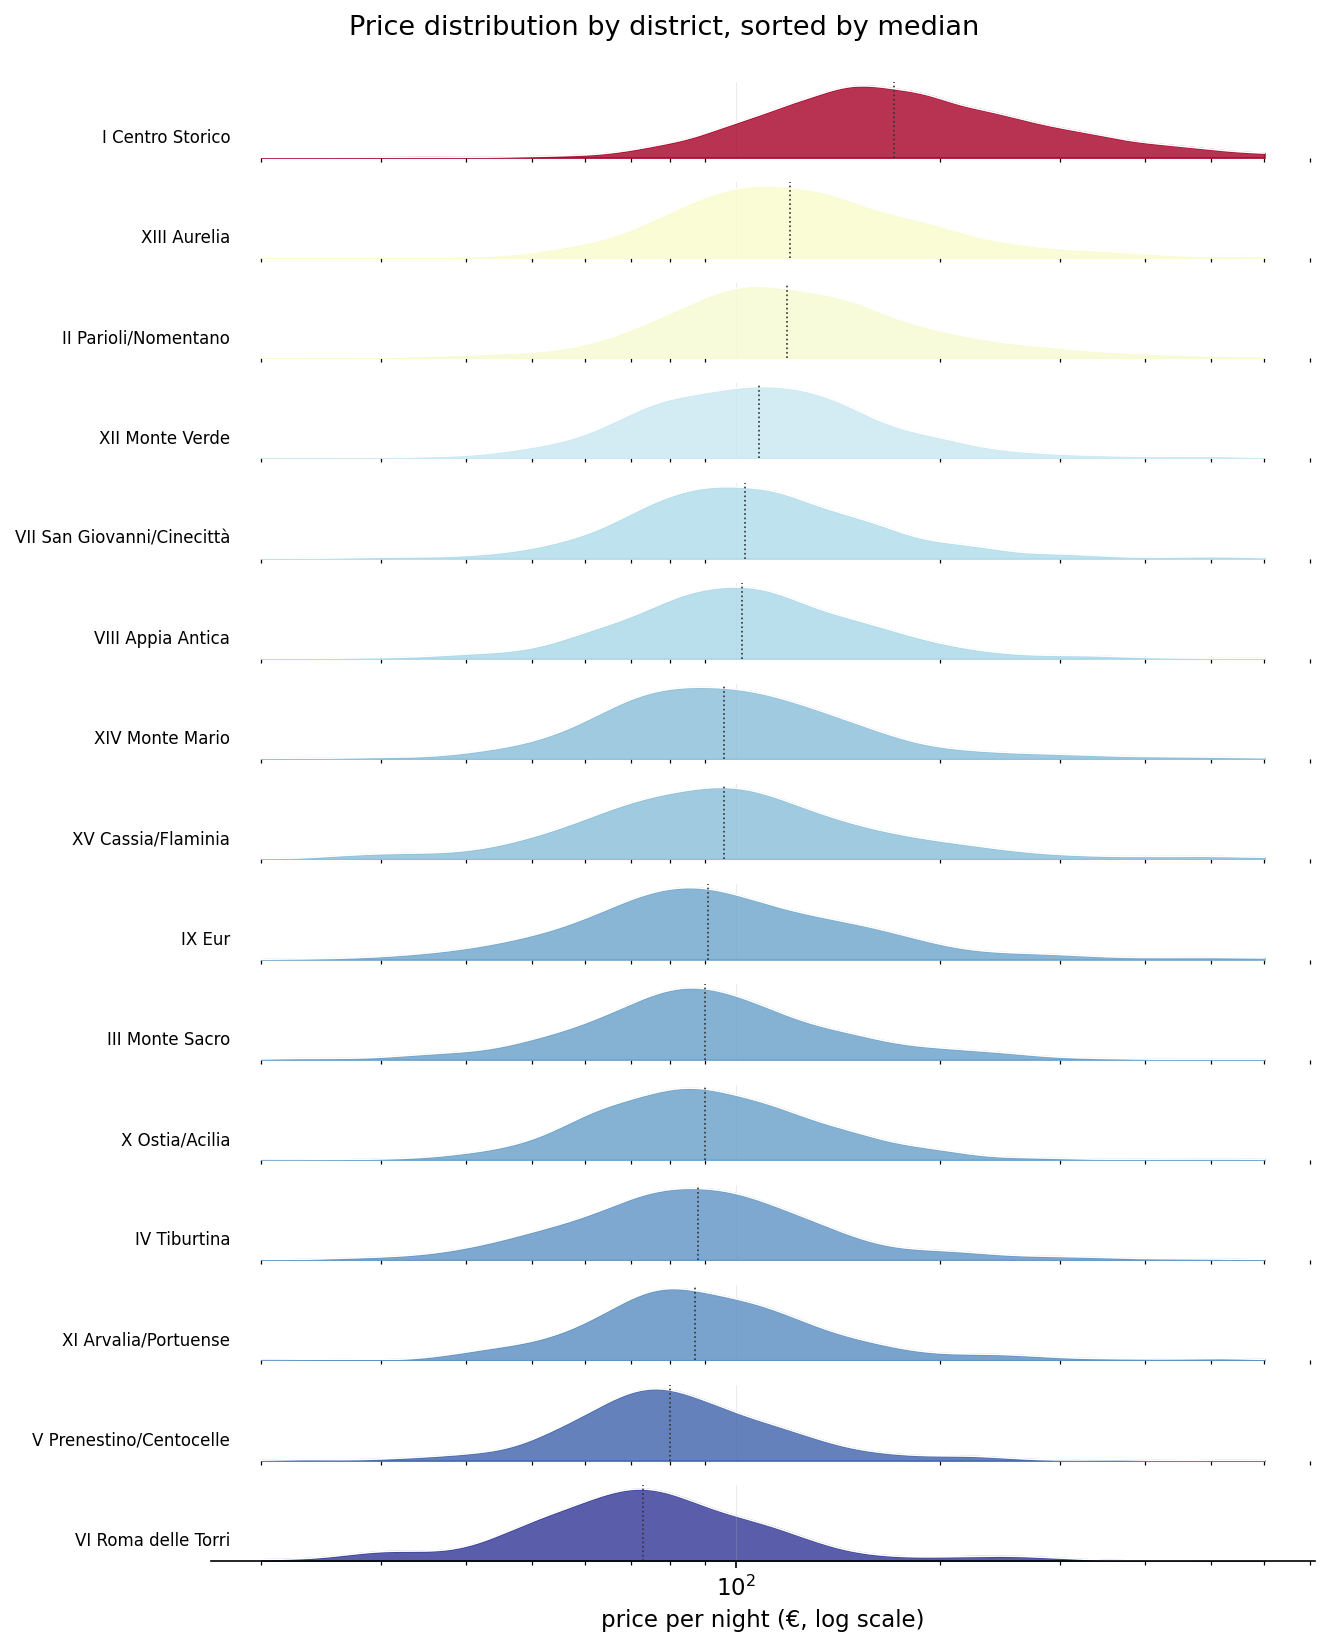

In [39]:
district_order = median_price_by_municipio.sort_values(ascending=False).index.tolist()

fig, axes = plt.subplots(len(district_order), 1, figsize=(9, 11), sharex=True)
plt.subplots_adjust(hspace=-0.6)

for i, district in enumerate(district_order):
    data = listings.loc[listings['neighbourhood_cleansed'] == district, 'price'].dropna()
    if len(data) < 5:
        continue
    log_data = np.log10(data)
    kde = gaussian_kde(log_data)
    x_grid = np.linspace(np.log10(20), np.log10(600), 300)
    y = kde(x_grid)
    y = y / y.max()

    color = plt.cm.RdYlBu_r((median_price_by_municipio[district] - median_price_by_municipio.min()) /
                              (median_price_by_municipio.max() - median_price_by_municipio.min()))
    axes[i].fill_between(10**x_grid, y, color=color, alpha=0.8, zorder=len(district_order)-i)
    axes[i].plot(10**x_grid, y, color='white', linewidth=0.8, zorder=len(district_order)-i)
    axes[i].axvline(median_price_by_municipio[district], color='#333333', linewidth=0.8, linestyle=':', zorder=len(district_order)-i+1)
    axes[i].set_xscale('log')
    axes[i].set_ylim(0, 1.05)
    axes[i].set_yticks([])
    axes[i].patch.set_alpha(0)
    for spine in ['top', 'right', 'left']:
        axes[i].spines[spine].set_visible(False)
    axes[i].text(18, 0.15, district, fontsize=8, ha='right', va='bottom')

axes[-1].set_xlabel('price per night (€, log scale)')
for ax in axes[:-1]:
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(bottom=False)

plt.suptitle('Price distribution by district, sorted by median', fontsize=13, y=0.995)
plt.tight_layout()
plt.show()

The full distribution tells a sharper story: most municipi's price distributions overlap heavily with each other, e.g. XIII Aurelia through VI Roma delle Torri form a tight, largely interchangeable band, all roughly unimodal and similar in width on the log scale, differing mainly in where their peak sits rather than in shape. I Centro Storico is the one genuine outlier on *both* dimensions at once: not just shifted right but visibly the widest distribution of any district, with real mass reaching past €300-400 that no other municipio comes close to matching. This means the center isn't simply "more expensive", it's more heterogeneous, spanning everything from budget rooms to genuine luxury, while the rest of Rome behaves as a comparatively uniform, tightly-clustered price band around €80-110. Even the cheapest districts (V Prenestino/Centocelle, VI Roma delle Torri) carry a visible right tail out to similar prices as everywhere else, a handful of expensive outlier listings exist everywhere, but only in Centro Storico do they represent a substantial share of the market rather than a rare exception. VI Roma delle Torri stands out from this otherwise-uniform group in a different way: a visible secondary bump sits distinctly below its main peak, a mild bimodality none of the other municipi show, hinting at a genuinely cheaper sub-segment within the district rather than just a wider spread around one center.

### 3.5 Price vs. Distance-to-Center Gradient

/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_21541/1923117432.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  listings['distance_to_center_km_restored'] = np.expm1(listings['distance_to_center_km_log'])


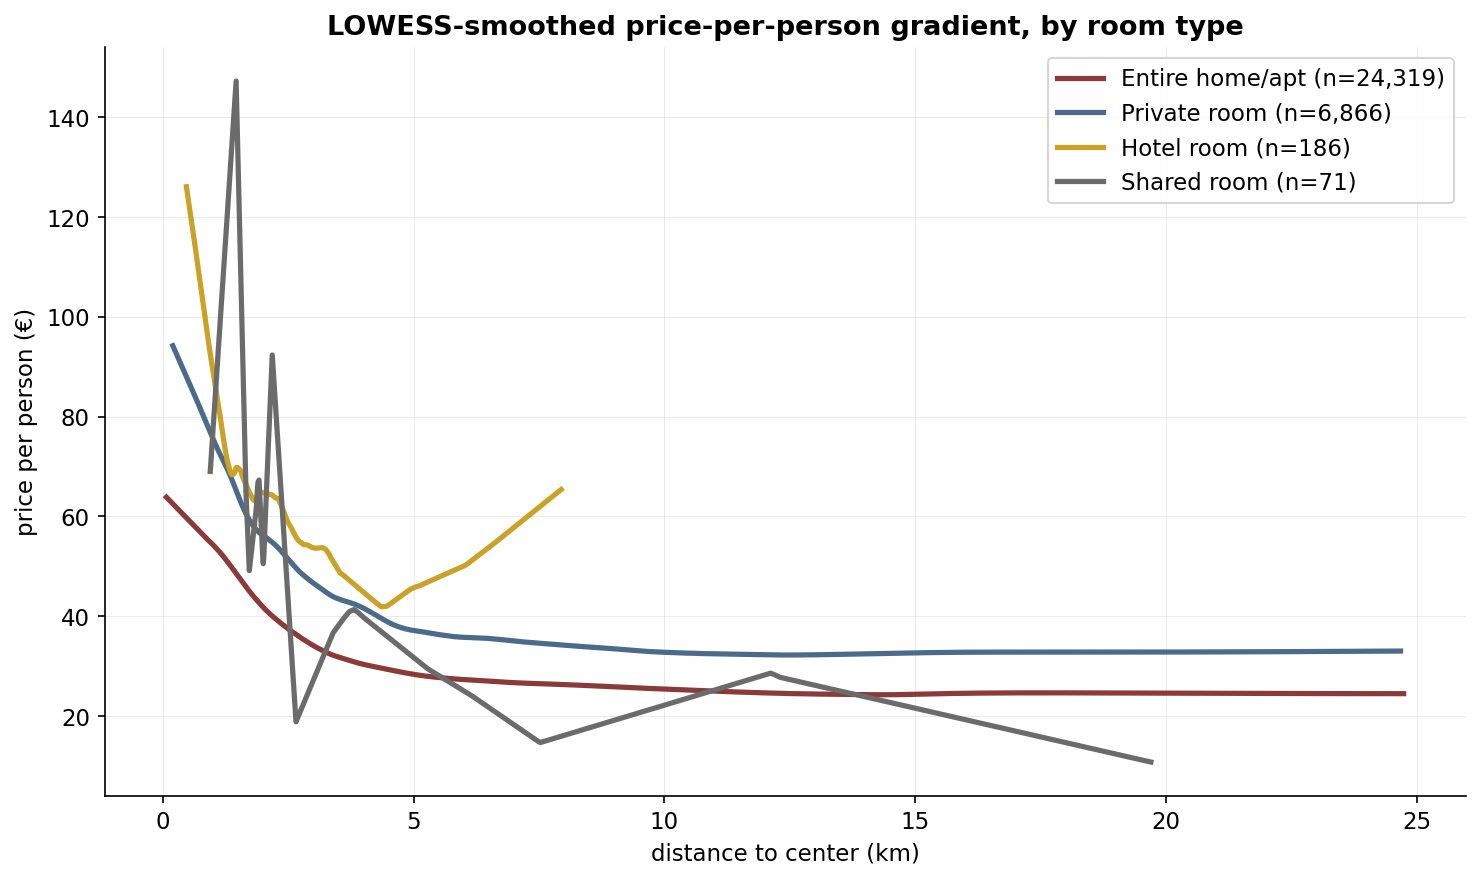

In [41]:
from statsmodels.nonparametric.smoothers_lowess import lowess

listings['distance_to_center_km_restored'] = np.expm1(listings['distance_to_center_km_log'])

MAIN_ROOM_TYPES = ['Entire home/apt', 'Private room']
ROOM_TYPE_COLORS = {
    'Entire home/apt': ROME_PALETTE['primary'],
    'Private room': ROME_PALETTE['secondary'],
    'Hotel room': ROME_PALETTE['accent'],
    'Shared room': ROME_PALETTE['neutral'],
}

grad_data = listings.dropna(subset=['distance_to_center_km_restored', 'price_per_person', 'room_type']).copy()
grad_data = grad_data[grad_data['price_per_person'] <= grad_data['price_per_person'].quantile(0.99)]
grad_data = grad_data[grad_data['distance_to_center_km_restored'] <= grad_data['distance_to_center_km_restored'].quantile(0.99)]

fig, ax = plt.subplots(figsize=(10, 6))
for rt in listings['room_type'].dropna().unique():
    sub = grad_data[grad_data['room_type'] == rt]
    if len(sub) < 30:
        continue
    smoothed = lowess(sub['price_per_person'], sub['distance_to_center_km_restored'], frac=0.3)
    ax.plot(smoothed[:, 0], smoothed[:, 1], color=ROOM_TYPE_COLORS.get(rt, '#999999'), linewidth=2.5,
            label=f'{rt} (n={len(sub):,})')

ax.set_xlabel('distance to center (km)')
ax.set_ylabel('price per person (€)')
ax.set_title('LOWESS-smoothed price-per-person gradient, by room type')
ax.legend()
plt.tight_layout()
plt.show()

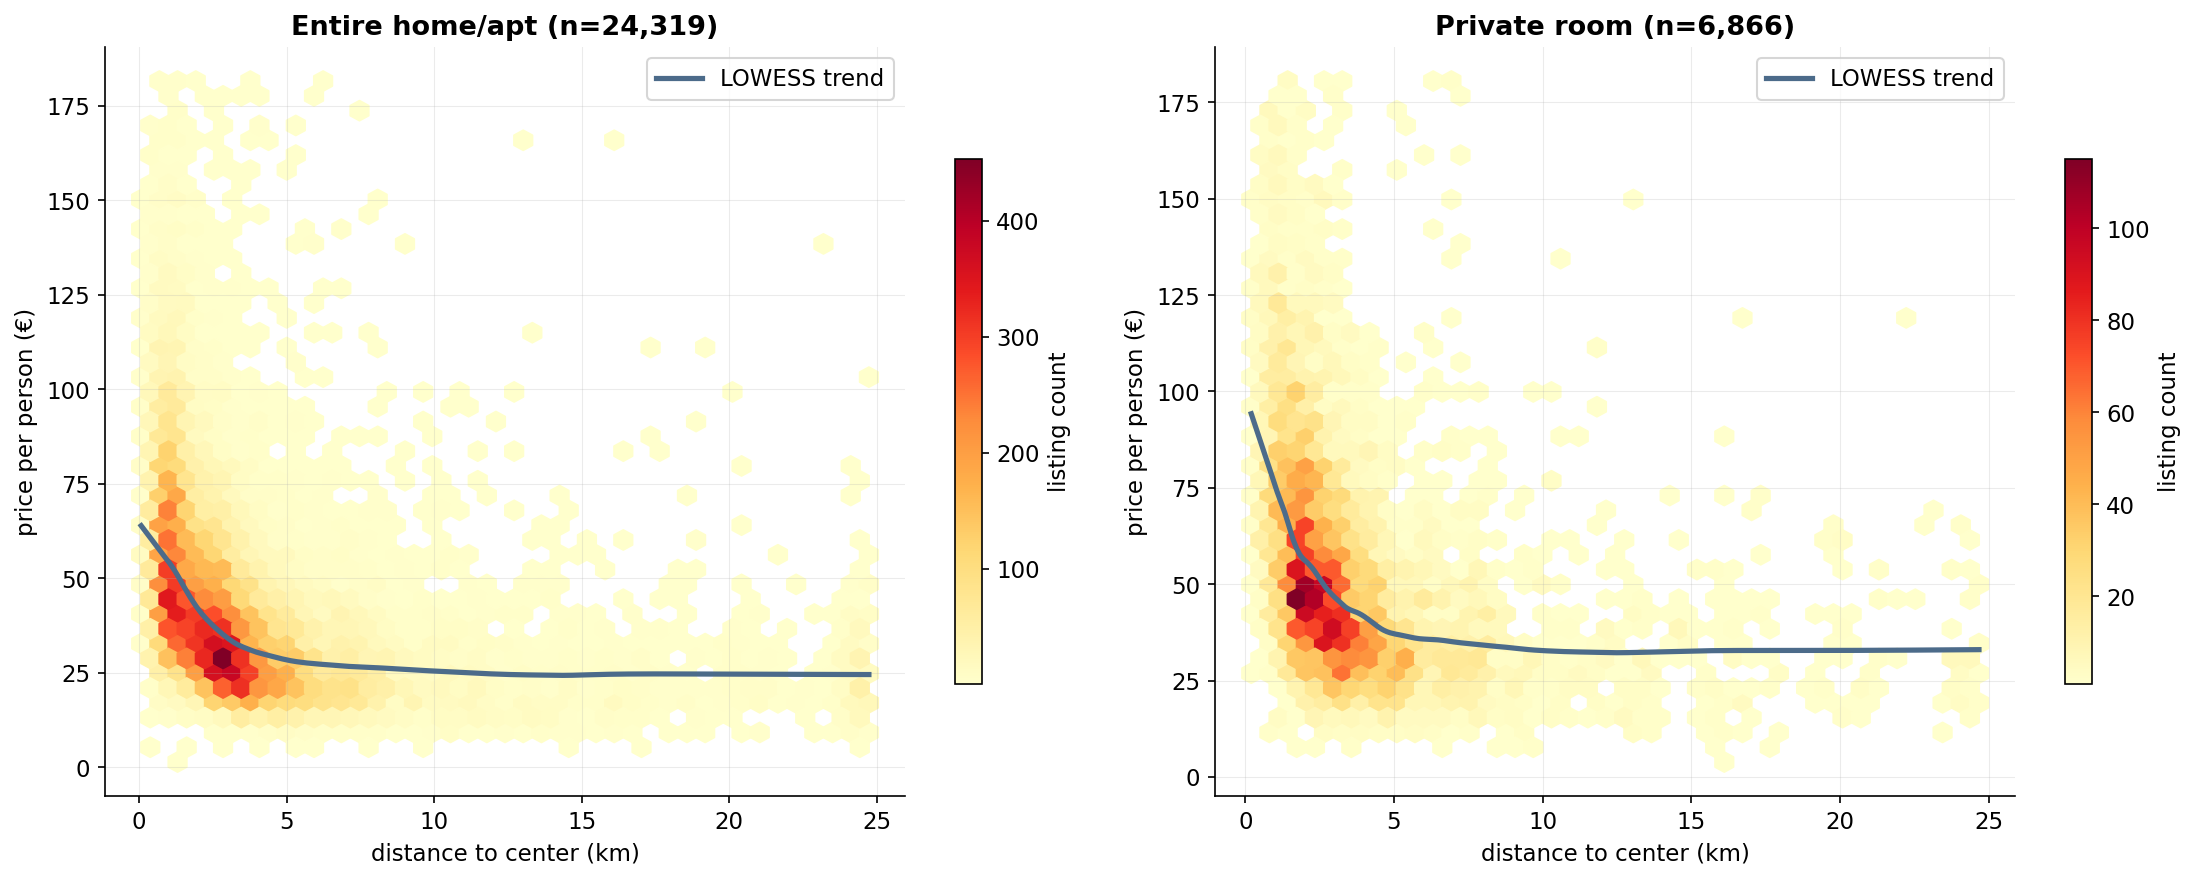

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, rt in zip(axes, MAIN_ROOM_TYPES):
    sub = grad_data[grad_data['room_type'] == rt]
    hb = ax.hexbin(sub['distance_to_center_km_restored'], sub['price_per_person'], gridsize=40, cmap='YlOrRd', mincnt=1)
    smoothed = lowess(sub['price_per_person'], sub['distance_to_center_km_restored'], frac=0.3)
    ax.plot(smoothed[:, 0], smoothed[:, 1], color=ROME_PALETTE['secondary'], linewidth=2.5, label='LOWESS trend')
    ax.set_xlabel('distance to center (km)')
    ax.set_ylabel('price per person (€)')
    ax.set_title(f'{rt} (n={len(sub):,})')
    ax.legend()
    plt.colorbar(hb, ax=ax, shrink=0.7, label='listing count')

plt.tight_layout()
plt.show()

`Entire home/apt` and `Private room` show a steep drop in the first ~5 km, then a long, nearly flat plateau, but at different levels. Entire units flatten around €25/person, private rooms around €35/person, a roughly €10 premium that holds consistently from 5 km out to the city edge. The hexbins confirm this isn't an artifact of sparse data: both room types have dense, high-count cells exactly where the steep drop happens (0-5 km), meaning the sharpest part of the center-periphery gradient is backed by thousands of listings, not a handful of outliers.

`Hotel room` and `Shared room` behave very differently, but for opposite reasons that both trace back to small sample size. `Hotel room`'s line is comparatively smoother and shows something genuinely distinct. Instead of flattening, it dips to a minimum around 5-6 km and then rises again toward 8 km, hinting at a second, more peripheral hotel cluster (plausibly near a business district or transit hub) rather than one continuous center-driven gradient. Though with only 186 listings, this shape should be treated as suggestive. `Shared room`'s line is the visibly least reliable of the four: with only 71 listings spread across 20 km, it swings wildly. This is LOWESS fitting noise from a handful of individual listings, not a real market pattern.

The core takeaway: the center-periphery price gradient is real and steep, but it's front-loaded, as nearly all of the effect happens within the first 5 km, and beyond that, distance stops mattering much for either of the market's two dominant room types.

### 3.6 Price Tier Geography

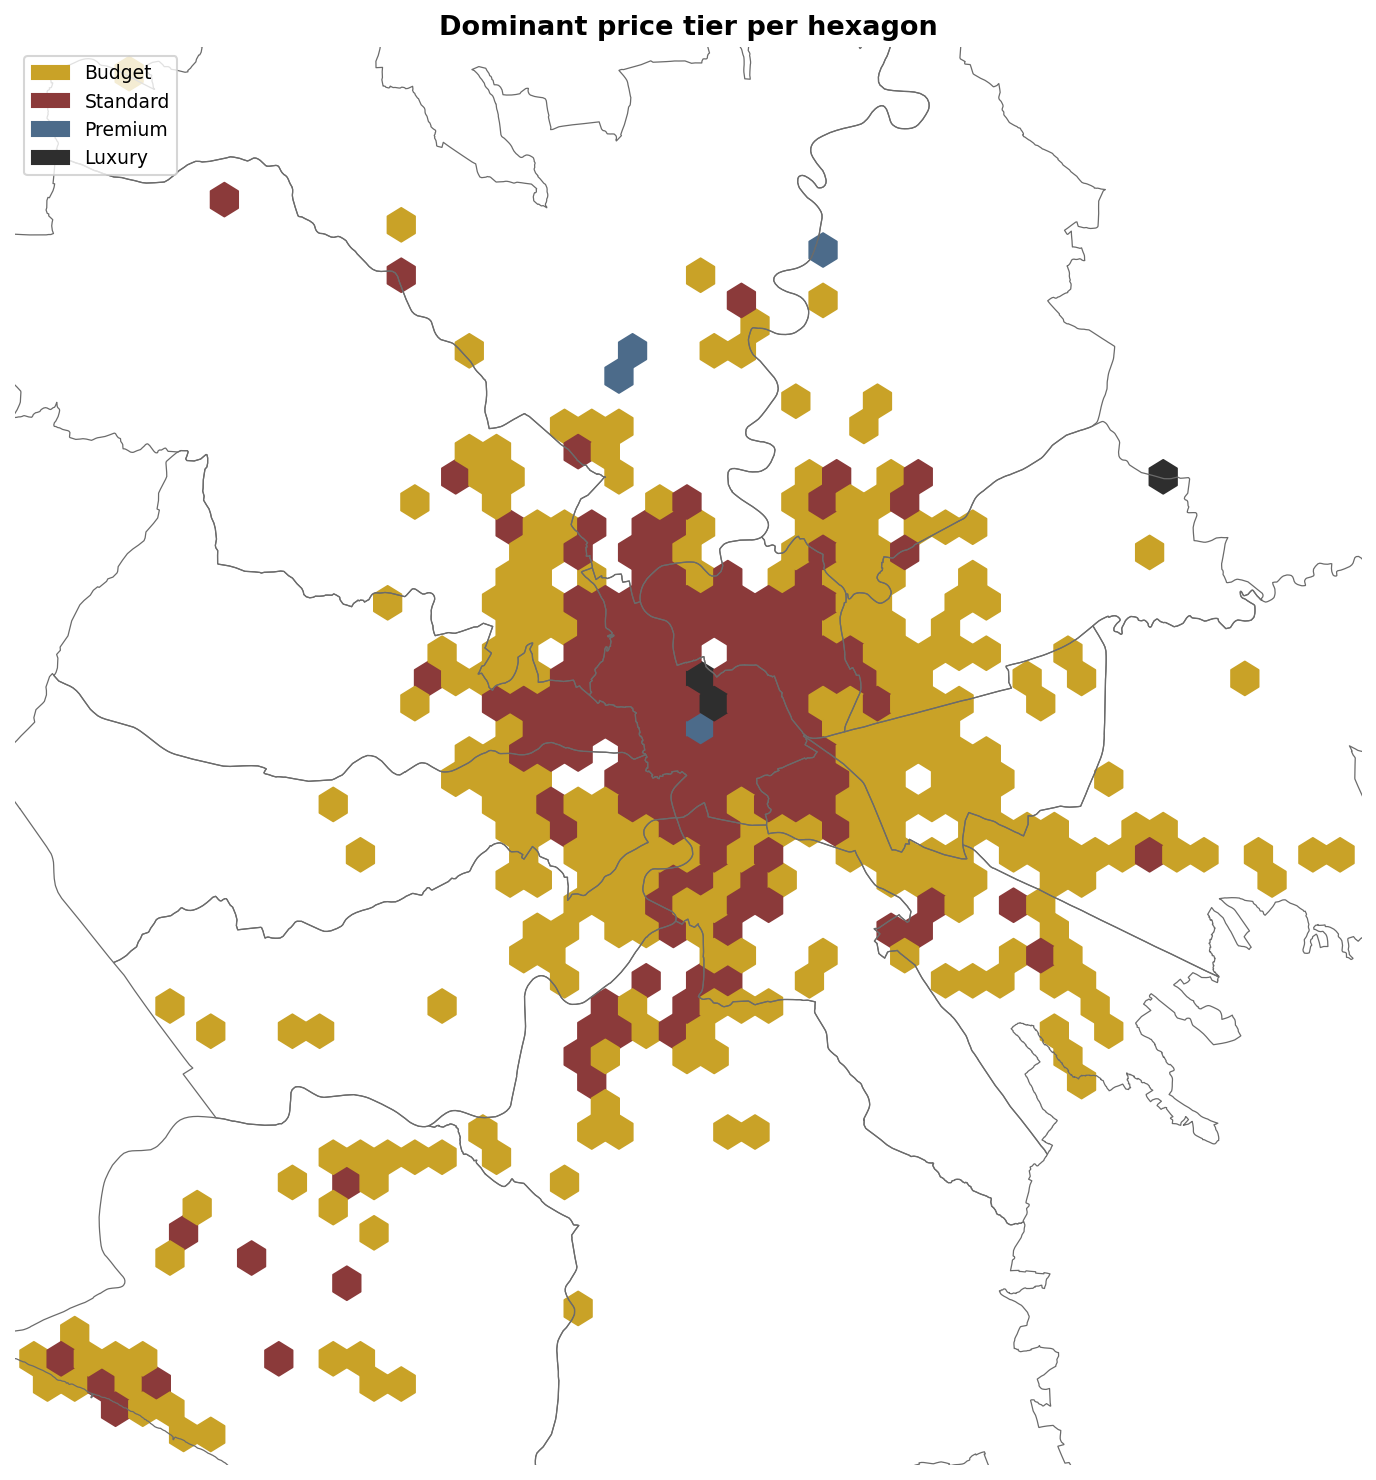

In [ ]:
TIER_HEX_COLORS = [TIER_COLORS[t] for t in TIER_NAMES]
TIER_CODES = {name: i for i, name in enumerate(TIER_NAMES)}

tier_geo = listings_geo.dropna(subset=['price_tier']).copy()
tier_geo['tier_code'] = tier_geo['price_tier'].map(TIER_CODES)

fig, ax = plt.subplots(figsize=(10, 10))
neighbourhoods.plot(ax=ax, color='none', edgecolor=ROME_PALETTE['neutral'], linewidth=0.6, zorder=2)

hb = ax.hexbin(tier_geo.geometry.x, tier_geo.geometry.y, C=tier_geo['tier_code'],
                reduce_C_function=mode_reduce, gridsize=65, mincnt=5,
                cmap=ListedColormap(TIER_HEX_COLORS), vmin=-0.5, vmax=3.5, zorder=1)

ax.set_xlim(lon_min - pad, lon_max + pad)
ax.set_ylim(lat_min - pad, lat_max + pad)
ax.set_title('Dominant price tier per hexagon')
legend_elements = [Patch(color=TIER_COLORS[t], label=t) for t in TIER_NAMES]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
ax.set_axis_off()
plt.tight_layout()
plt.show()

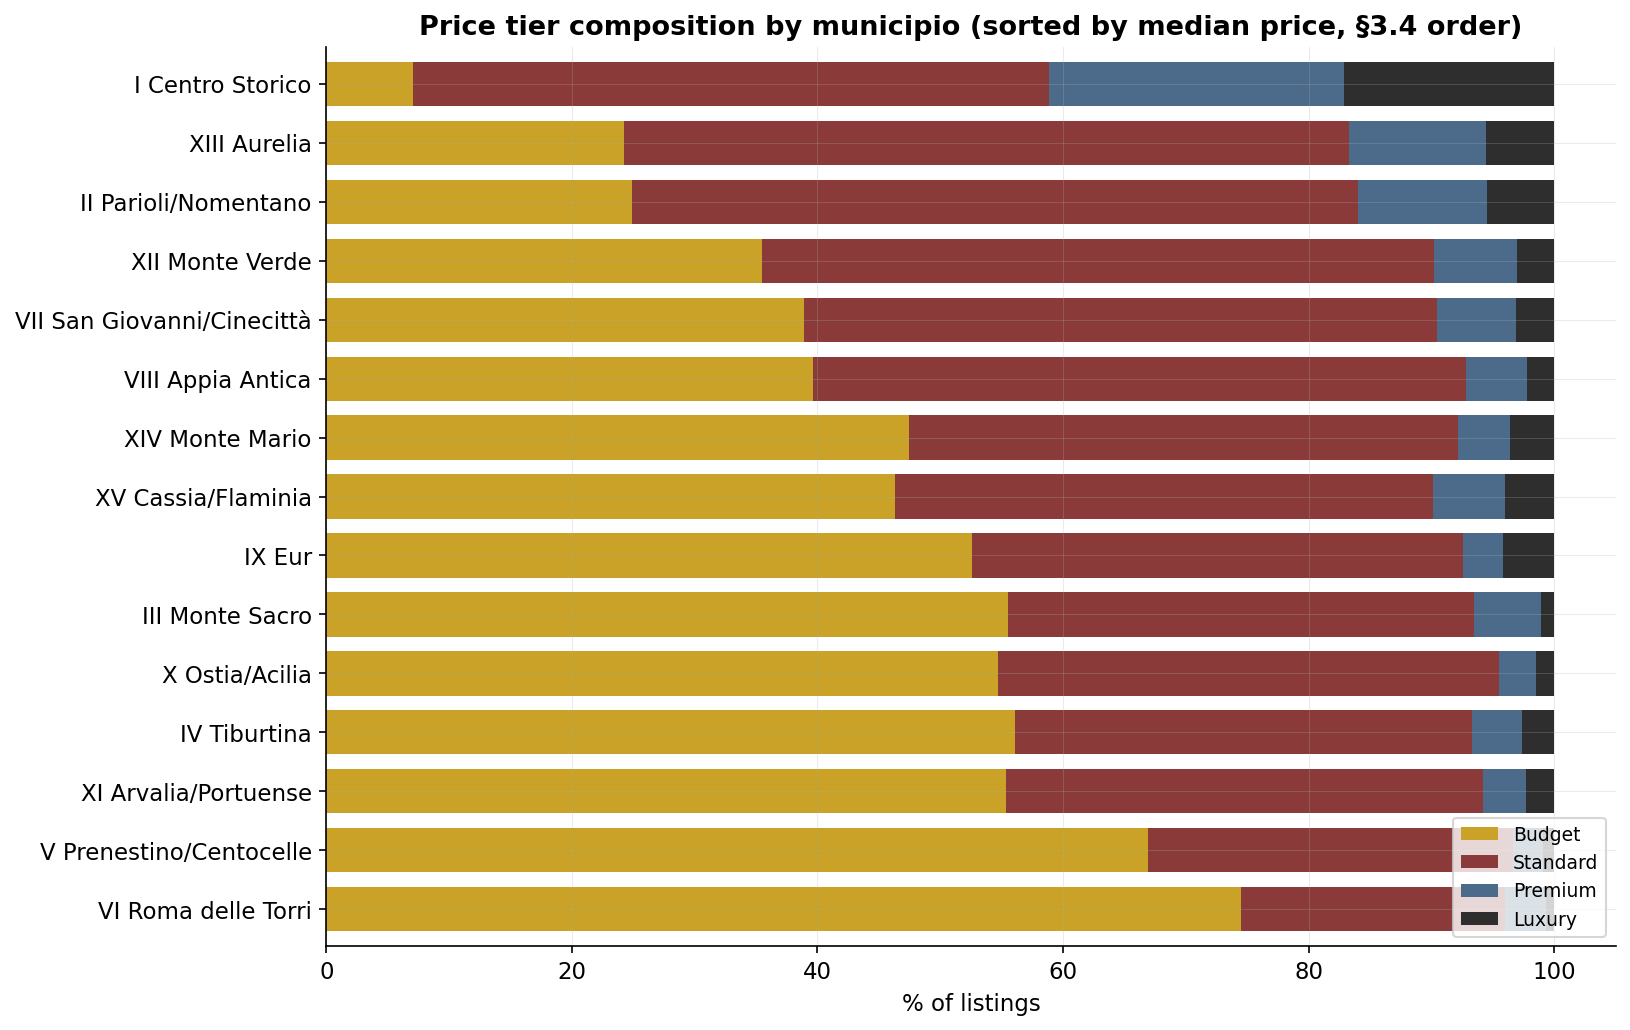

price_tier,Budget,Luxury,Premium,Standard
neighbourhood_cleansed,,,,
I Centro Storico,7.1,17.2,24.0,51.7
XIII Aurelia,24.2,5.6,11.1,59.1
II Parioli/Nomentano,24.9,5.5,10.5,59.1
XII Monte Verde,35.5,3.0,6.7,54.7
VII San Giovanni/Cinecittà,38.9,3.1,6.4,51.6
VIII Appia Antica,39.7,2.2,5.0,53.2
XIV Monte Mario,47.5,3.6,4.2,44.7
XV Cassia/Flaminia,46.3,4.0,5.9,43.8
IX Eur,52.6,4.1,3.3,39.9


In [ ]:
tier_by_municipio = pd.crosstab(listings['neighbourhood_cleansed'], listings['price_tier'], normalize='index').mul(100)
tier_by_municipio = tier_by_municipio.reindex(index=median_price_by_municipio.sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(11, 7))
tier_by_municipio[TIER_NAMES].plot(kind='barh', stacked=True, ax=ax, color=TIER_HEX_COLORS, width=0.75)
ax.set_xlabel('% of listings')
ax.set_ylabel('')
ax.set_title('Price tier composition by municipio (sorted by median price, §3.4 order)')
ax.legend(loc='lower right', fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

display(tier_by_municipio.round(1))

**Observations:**

Price tier follows a genuinely clean radial pattern: the hexbin map shows a near-solid Standard core surrounded by a Budget ring, both roughly concentric around Centro Storico. The municipio table makes the same story precise: Budget share climbs almost monotonically moving down the price-sorted list, from just 7.1% in Centro Storico to 74.5% in VI Roma delle Torri, a more than tenfold difference. Premium and Luxury together are effectively a center-only phenomenon, as I Centro Storico alone holds 41.2% Premium+Luxury listings, while every other district sits in the single digits, several barely above 3%.

X Ostia/Acilia's price tier profile is unremarkable, as it's 54.7% Budget, near-identical to its immediate distance-based neighbors (III Monte Sacro, XI Arvalia/Portuense). This confirms Ostia's distinct identity, already established via `text_persona` in the NLP notebook, is a semantic/textual signature.

One black (Luxury-dominant) hexagon appears well outside the city core, isolated single cell rather than part of any cluster. It's almost certainly individual high-end outlier properties (villas, estates) rather than evidence of a second luxury hub, consistent with how thinly Luxury is represented everywhere outside Centro Storico.

### 3.7 Housing Type Geography

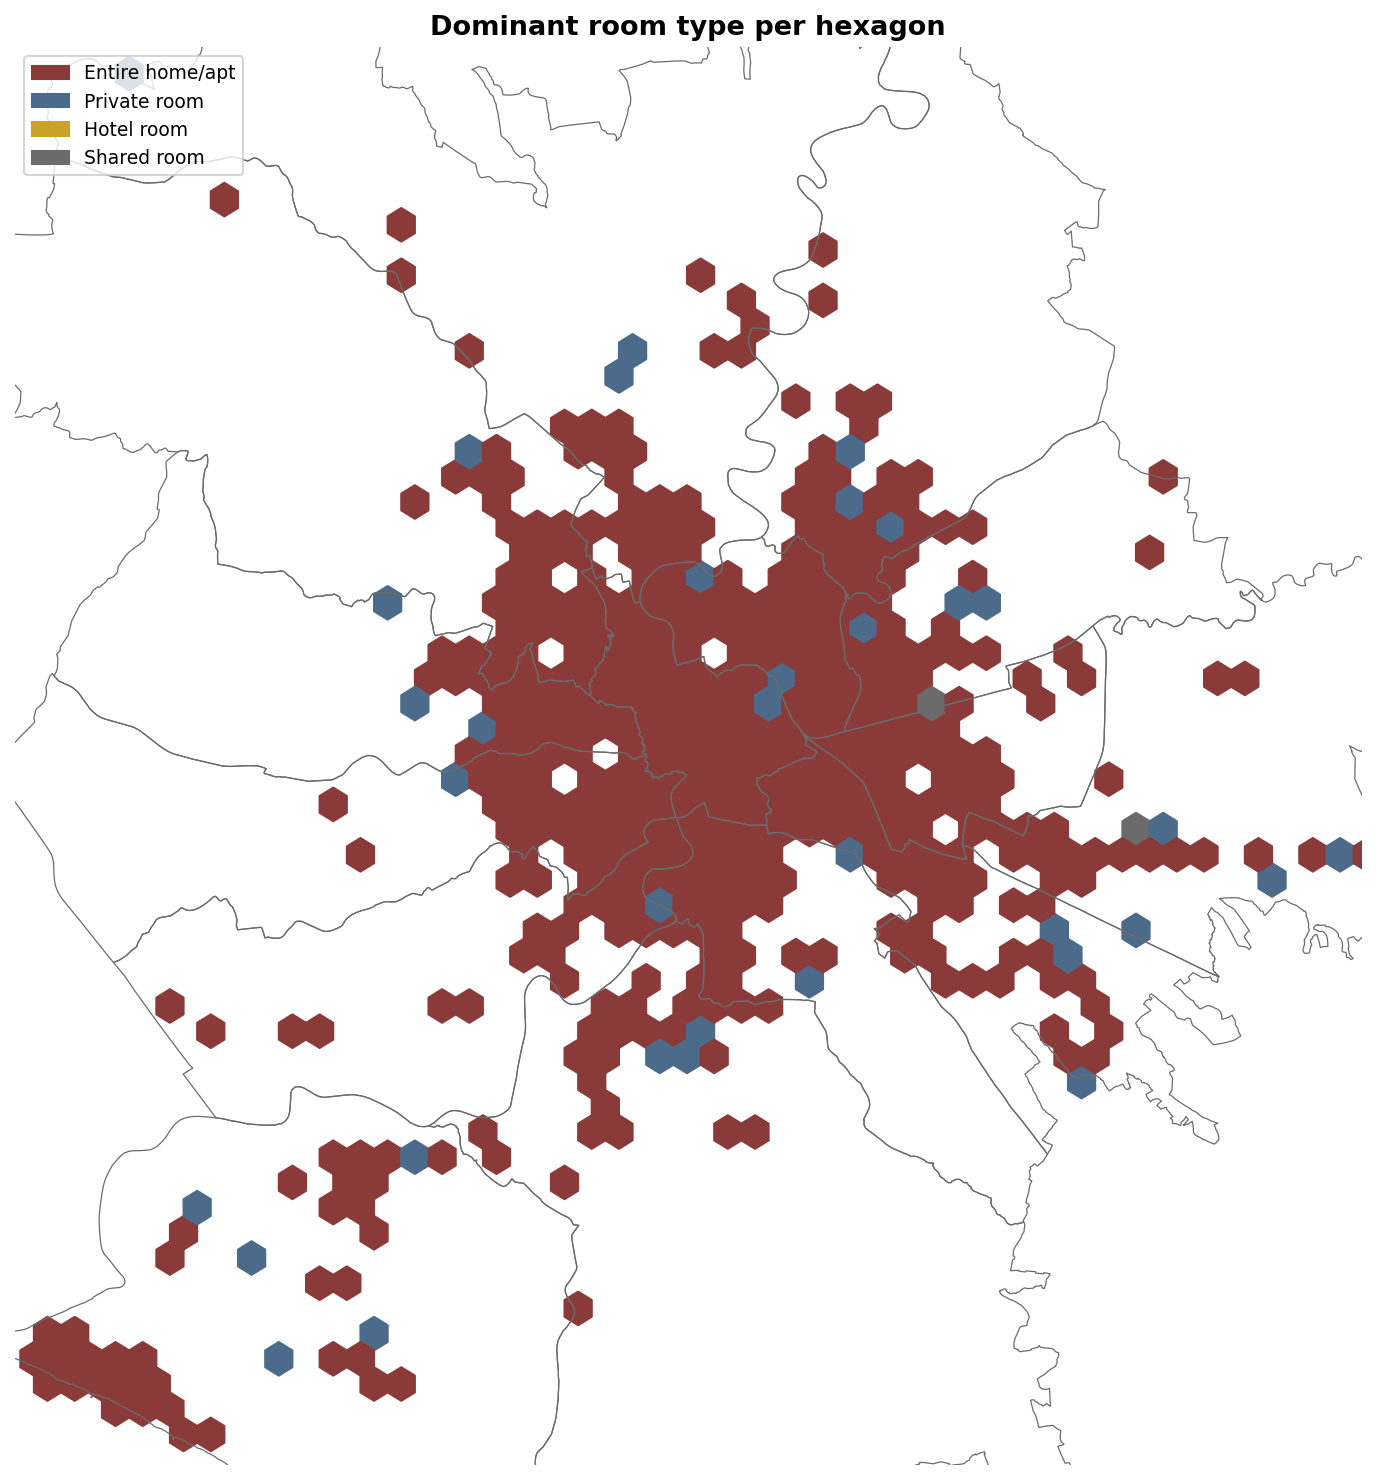

In [45]:
from scipy import stats as scipy_stats
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

ROOM_TYPE_CODES = {'Entire home/apt': 0, 'Private room': 1, 'Hotel room': 2, 'Shared room': 3}
ROOM_TYPE_HEX_COLORS = [ROME_PALETTE['primary'], ROME_PALETTE['secondary'], ROME_PALETTE['accent'], ROME_PALETTE['neutral']]

rt_geo = listings_geo.dropna(subset=['room_type']).copy()
rt_geo['room_type_code'] = rt_geo['room_type'].map(ROOM_TYPE_CODES)

def mode_reduce(codes):
    return scipy_stats.mode(codes, keepdims=False).mode

fig, ax = plt.subplots(figsize=(10, 10))
neighbourhoods.plot(ax=ax, color='none', edgecolor=ROME_PALETTE['neutral'], linewidth=0.6, zorder=2)

# mincnt=5: a hexagon needs at least 5 listings before its "dominant type" is trusted
hb = ax.hexbin(rt_geo.geometry.x, rt_geo.geometry.y, C=rt_geo['room_type_code'],
                reduce_C_function=mode_reduce, gridsize=65, mincnt=5,
                cmap=ListedColormap(ROOM_TYPE_HEX_COLORS), vmin=-0.5, vmax=3.5, zorder=1)

ax.set_xlim(lon_min - pad, lon_max + pad)
ax.set_ylim(lat_min - pad, lat_max + pad)
ax.set_title('Dominant room type per hexagon')
legend_elements = [Patch(color=c, label=rt) for rt, c in zip(ROOM_TYPE_CODES.keys(), ROOM_TYPE_HEX_COLORS)]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
ax.set_axis_off()
plt.tight_layout()
plt.show()

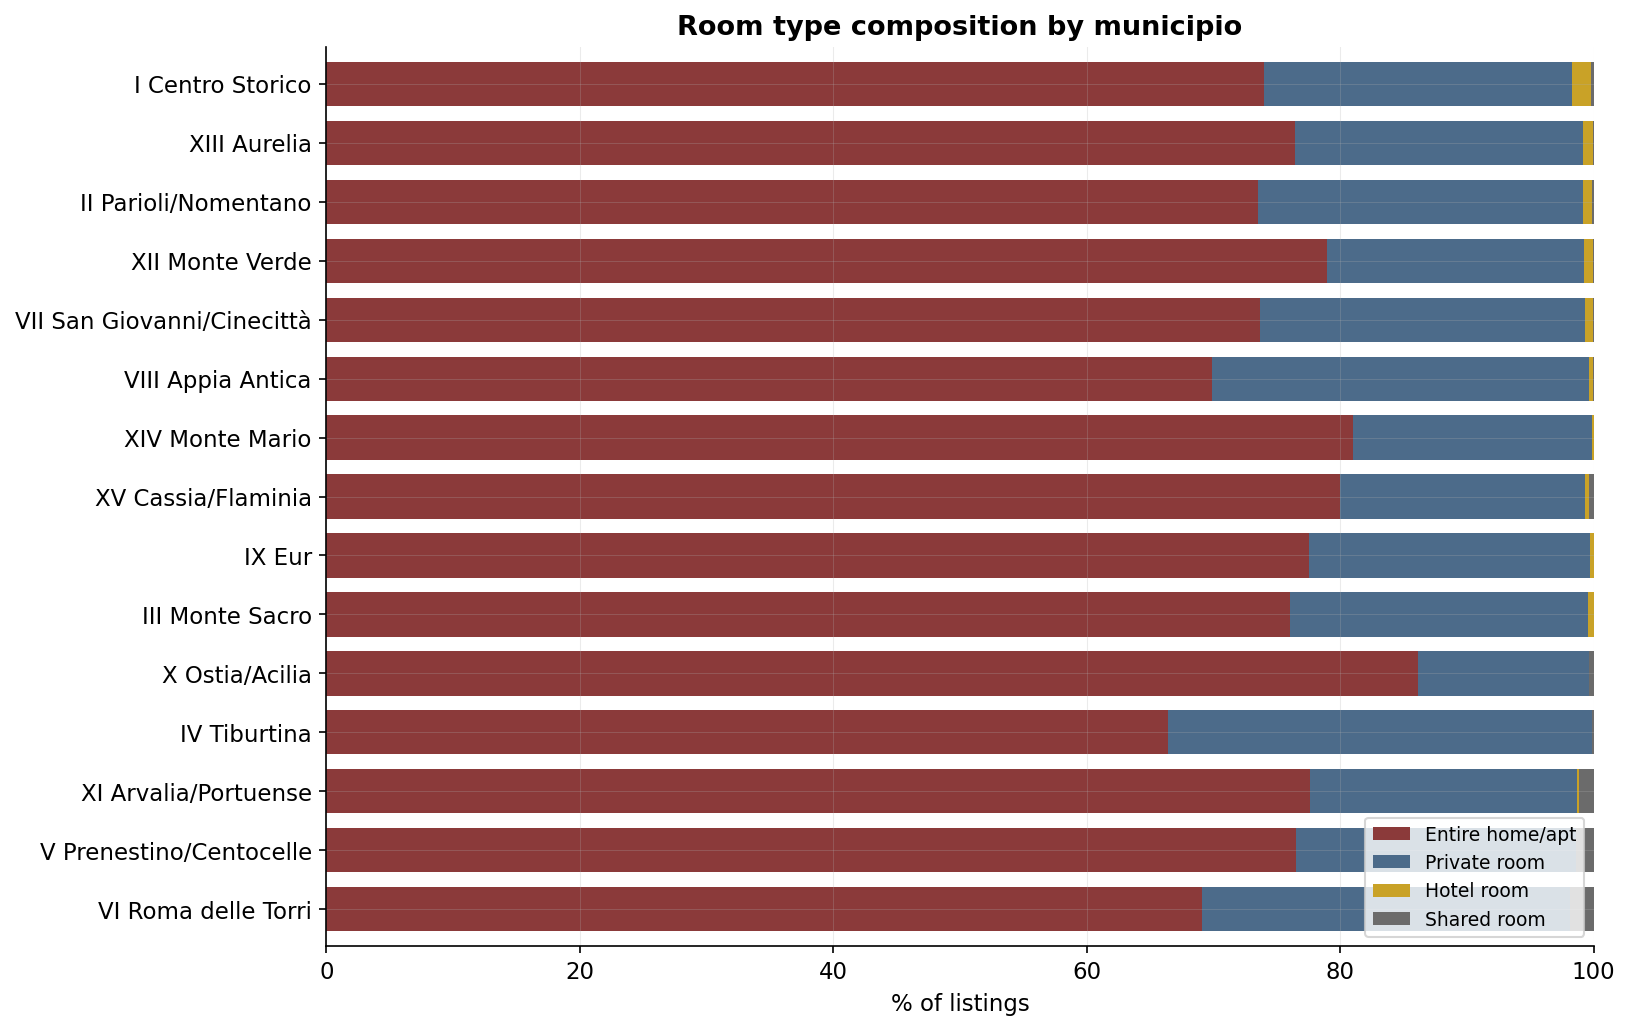

room_type,Entire home/apt,Hotel room,Private room,Shared room
neighbourhood_cleansed,,,,
I Centro Storico,74.0,1.4,24.3,0.3
XIII Aurelia,76.4,0.8,22.7,0.0
II Parioli/Nomentano,73.5,0.7,25.6,0.1
XII Monte Verde,79.0,0.7,20.3,0.1
VII San Giovanni/Cinecittà,73.7,0.7,25.6,0.0
VIII Appia Antica,69.9,0.3,29.8,0.1
XIV Monte Mario,81.0,0.1,18.8,0.0
XV Cassia/Flaminia,80.0,0.4,19.3,0.4
IX Eur,77.5,0.3,22.2,0.0


In [46]:
rt_by_municipio = pd.crosstab(listings['neighbourhood_cleansed'], listings['room_type'], normalize='index').mul(100)
rt_by_municipio = rt_by_municipio.reindex(index=median_price_by_municipio.sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(11, 7))
rt_by_municipio[list(ROOM_TYPE_CODES.keys())].plot(kind='barh', stacked=True, ax=ax,
                                                      color=ROOM_TYPE_HEX_COLORS, width=0.75)
ax.set_xlabel('% of listings')
ax.set_ylabel('')
ax.set_title('Room type composition by municipio')
ax.legend(loc='lower right', fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

rt_table = rt_by_municipio.round(1)
display(rt_table)

Both views tell the same story: `Entire home/apt` dominates almost everywhere, not just the tourist core. The hexbin map is nearly solid terracotta across the whole city. `Private room` (blue) appears only as scattered individual cells, mostly on the fringes and along the eastern corridor toward Ciampino, never forming a coherent zone of its own.

The table confirms this numerically: every municipio sits within a narrow 66-86% `Entire home/apt` band, with no clean center-vs-periphery split. If anything, the pattern runs opposite to the original hypothesis, X Ostia/Acilia, the most peripheral district, has the *highest* entire-home share (86.2%) of any municipio, while IV Tiburtina, a mid-distance eastern district, has the *lowest* (66.4%) and the largest private-room share (33.4%).

This means room type and price tell genuinely different geographic stories: price vs. distance to center showed price radiating outward from the center in a clean gradient, but housing type doesn't follow that same radial logic at all. It's driven by something else rather than distance itself. `Hotel room` and `Shared room` stay rare everywhere and don't cluster in any one place.

### 3.8 Geography of the Market Summary

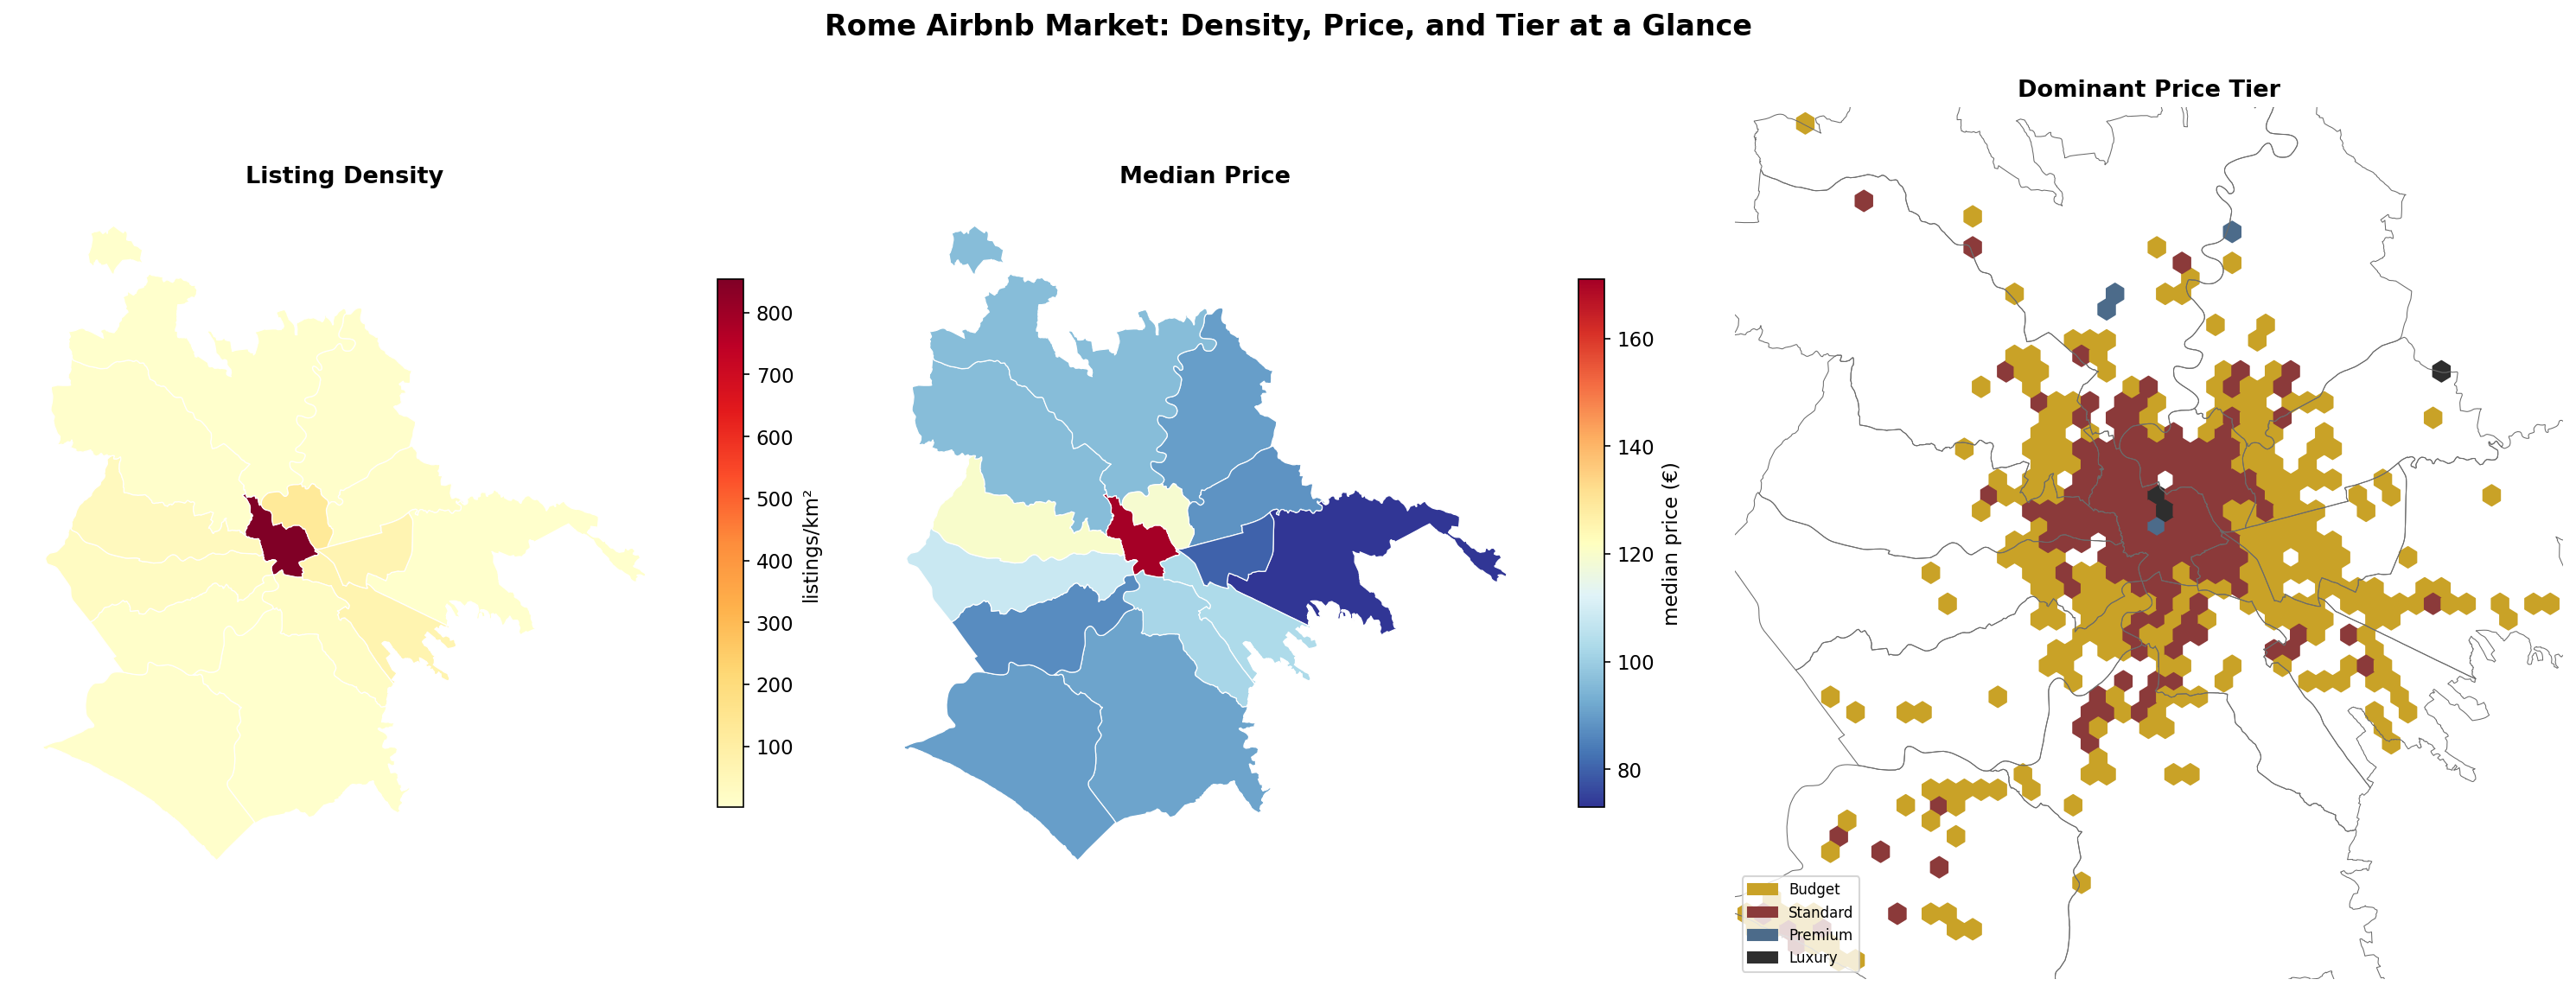

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7.5))

# panel 1: density
neighbourhoods.plot(column='density_per_km2', ax=axes[0], cmap='YlOrRd', edgecolor='white', linewidth=0.6,
                     legend=True, legend_kwds={'label': 'listings/km²', 'shrink': 0.6})
axes[0].set_title('Listing Density', fontsize=13, fontweight='bold')
axes[0].set_axis_off()

# panel 2: price
neighbourhoods.plot(column='median_price', ax=axes[1], cmap='RdYlBu_r', edgecolor='white', linewidth=0.6,
                     legend=True, legend_kwds={'label': 'median price (€)', 'shrink': 0.6})
axes[1].set_title('Median Price', fontsize=13, fontweight='bold')
axes[1].set_axis_off()

# panel 3: dominant price tier (fine-grained hexbin)
neighbourhoods.plot(ax=axes[2], color='none', edgecolor=ROME_PALETTE['neutral'], linewidth=0.5, zorder=2)
hb = axes[2].hexbin(tier_geo.geometry.x, tier_geo.geometry.y, C=tier_geo['tier_code'],
                      reduce_C_function=mode_reduce, gridsize=65, mincnt=5,
                      cmap=ListedColormap(TIER_HEX_COLORS), vmin=-0.5, vmax=3.5, zorder=1)
axes[2].set_xlim(lon_min - pad, lon_max + pad)
axes[2].set_ylim(lat_min - pad, lat_max + pad)
axes[2].set_title('Dominant Price Tier', fontsize=13, fontweight='bold')
legend_elements = [Patch(color=TIER_COLORS[t], label=t) for t in TIER_NAMES]
axes[2].legend(handles=legend_elements, loc='lower left', fontsize=8)
axes[2].set_axis_off()

plt.suptitle('Rome Airbnb Market: Density, Price, and Tier', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Rome's Airbnb market has exactly one center of gravity, and every geographic axis examined here orbits it in a clean, near-concentric pattern. I Centro Storico alone holds roughly 49% of all listings on just 20.5 km², is the only district where Premium and Luxury together form a substantial share (41.2%) rather than a rare exception, and its price distribution is both the highest-shifted and the widest of any municipio. The center isn't simply more expensive, it's more heterogeneous, spanning everything from budget rooms to genuine luxury while the rest of Rome behaves as a comparatively uniform, tightly-clustered band. Moving outward, both density and price fall off in a steady staircase with no second hub anywhere in the city, and the price-distance relationship is front-loaded: nearly all of it plays out within the first 5 km, after which distance stops mattering much.

Housing *type*, however, breaks this pattern entirely. `room_type` composition stays remarkably flat across all 15 municipi (66-86% entire-home everywhere), showing no center-periphery logic at all. X Ostia/Acilia makes this split concrete: distinctively homogeneous in housing type (86.2% entire home, the market's highest) yet structurally unremarkable in both price tier and density, confirming that whatever makes Ostia distinct is already identified via `text_persona` in the NLP notebook and lives in the text guests and hosts write.